In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition importA PC
from sklearn.ensemble import RandomForestRegressor
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.api as sm
from statsmodels.formula.api import ols

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [39]:
# 读取数据
data = pd.read_excel('数据汇总.xlsx')
conditions = pd.read_excel('实验条件.xlsx')
data.head(100)

,序号,断裂强力,断裂伸长率,撕裂强力,透气率,透湿率,柔软度,折皱回复角
0,基布,1484.79000,1.217200,180.64324,201.88,3287.632509,3.66,161.983
1,1,1728.29688,1.052536,179.65600,178.76,3180.212014,1.18,148.760
2,NaN,1781.91810,1.038690,178.19590,172.78,3137.809187,1.18,148.015
3,NaN,1784.60990,1.106284,170.94500,186.02,4197.879859,1.10,151.290
4,2,1177.06720,0.921800,115.25870,202.58,3307.420495,2.13,157.000
5,NaN,1142.41540,0.869043,121.75290,211.87,2874.911661,2.19,156.190
6,NaN,1121.36011,0.854600,111.94410,205.58,3137.809187,2.08,159.510
7,3,1182.67890,0.878159,102.84510,122.4,2862.190813,2.94,161.500
8,NaN,1199.74011,0.922368,97.52840,126.15,2968.197880,2.85,163.095
9,NaN,1233.62130,0.907578,94.51560,124.7,3010.600707,2.93,161.990


In [40]:
conditions.head(100)

,试验号,因素1（树脂含量）,因素2（固化温度）,因素3（减量程度）
0,1,15wt%,100℃,0.0
1,2,15wt%,110℃,0.1
2,3,15wt%,120℃,0.2
3,4,15wt%,130℃,0.3
4,5,20wt%,100℃,0.1
5,6,20wt%,110℃,0.0
6,7,20wt%,120℃,0.3
7,8,20wt%,130℃,0.2
8,9,25wt%,100℃,0.2
9,10,25wt%,110℃,0.3


In [42]:
# 数据预处理
# 填充序号列的NaN值
data['序号'] = data['序号'].fillna(method='ffill')

# 删除基布数据
base_fabric = data[data['序号'] == '基布']
data = data[data['序号'] != '基布']
data.head(16)

# 将性能指标列转换为数值类型
performance = ['断裂强力', '断裂伸长率', '撕裂强力', '透气率', '透湿率', '柔软度', '折皱回复角']
for col in performance:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# 计算3组实验的平均值
data_mean = data.groupby('序号').mean().reset_index()


# 处理实验条件数据
conditions['因素1（树脂含量）'] = conditions['因素1（树脂含量）'].str.rstrip('wt%').astype(float)
conditions['因素2（固化温度）'] = conditions['因素2（固化温度）'].str.rstrip('℃').astype(float)

# 合并数据
merged_data = pd.merge(data_mean, conditions, left_on='序号', right_on='试验号')

# 标准化数据
scaler = StandardScaler()
features = ['因素1（树脂含量）', '因素2（固化温度）', '因素3（减量程度）']
performance = ['断裂强力', '断裂伸长率', '撕裂强力', '透气率', '透湿率', '柔软度', '折皱回复角']
scaled_data = pd.DataFrame(scaler.fit_transform(merged_data[features + performance]), columns=features + performance)

,序号,断裂强力,断裂伸长率,撕裂强力,透气率,透湿率,柔软度,折皱回复角
0,1,1764.941627,1.065837,176.265633,179.186667,3505.300353,1.153333,149.355000
1,2,1146.947570,0.881814,116.318567,206.676667,3106.713781,2.133333,157.566667
2,3,1205.346770,0.902702,98.296367,124.416667,2946.996466,2.906667,162.195000
3,4,1218.921490,0.977072,102.224173,90.350000,3010.600707,3.433333,166.575000
4,5,1162.497380,0.888027,111.170600,328.350000,2595.053004,2.036667,158.593333
5,6,1655.559607,1.057166,159.909667,229.083333,2607.773852,0.993333,150.283333
6,7,1200.639580,0.924602,104.099333,137.303333,2558.303887,3.030000,168.465000
7,8,1235.663717,0.945407,110.877500,143.020000,2713.780919,2.936667,168.303333
8,9,1184.156600,0.863231,91.936067,169.503333,2473.498233,2.193333,163.190000
9,10,1234.010727,0.957344,91.014800,88.276667,2636.042403,2.820000,166.298333



自变量X的描述性统计：
       因素1（树脂含量）   因素2（固化温度）  因素3（减量程度）
count  16.000000   16.000000   16.00000
mean   22.500000  115.000000    0.15000
std     5.773503   11.547005    0.11547
min    15.000000  100.000000    0.00000
25%    18.750000  107.500000    0.07500
50%    22.500000  115.000000    0.15000
75%    26.250000  122.500000    0.22500
max    30.000000  130.000000    0.30000

因变量y的描述性统计：
              断裂强力      断裂伸长率        撕裂强力         透气率          透湿率        柔软度  \
count    16.000000  16.000000   16.000000   16.000000    16.000000  16.000000   
mean   1331.605010   0.943243  117.269888  183.651667  2626.766784   2.065000   
std     235.218585   0.078591   26.151431   73.984368   375.735012   0.856626   
min    1146.947570   0.800592   91.014800   88.276667  2124.381625   0.850000   
25%    1184.775505   0.899033  101.242222  134.081667  2415.194346   1.383333   
50%    1222.899645   0.920158  109.622917  174.345000  2601.413428   2.085000   
75%    1357.926652   0.985015  123.596858  218.

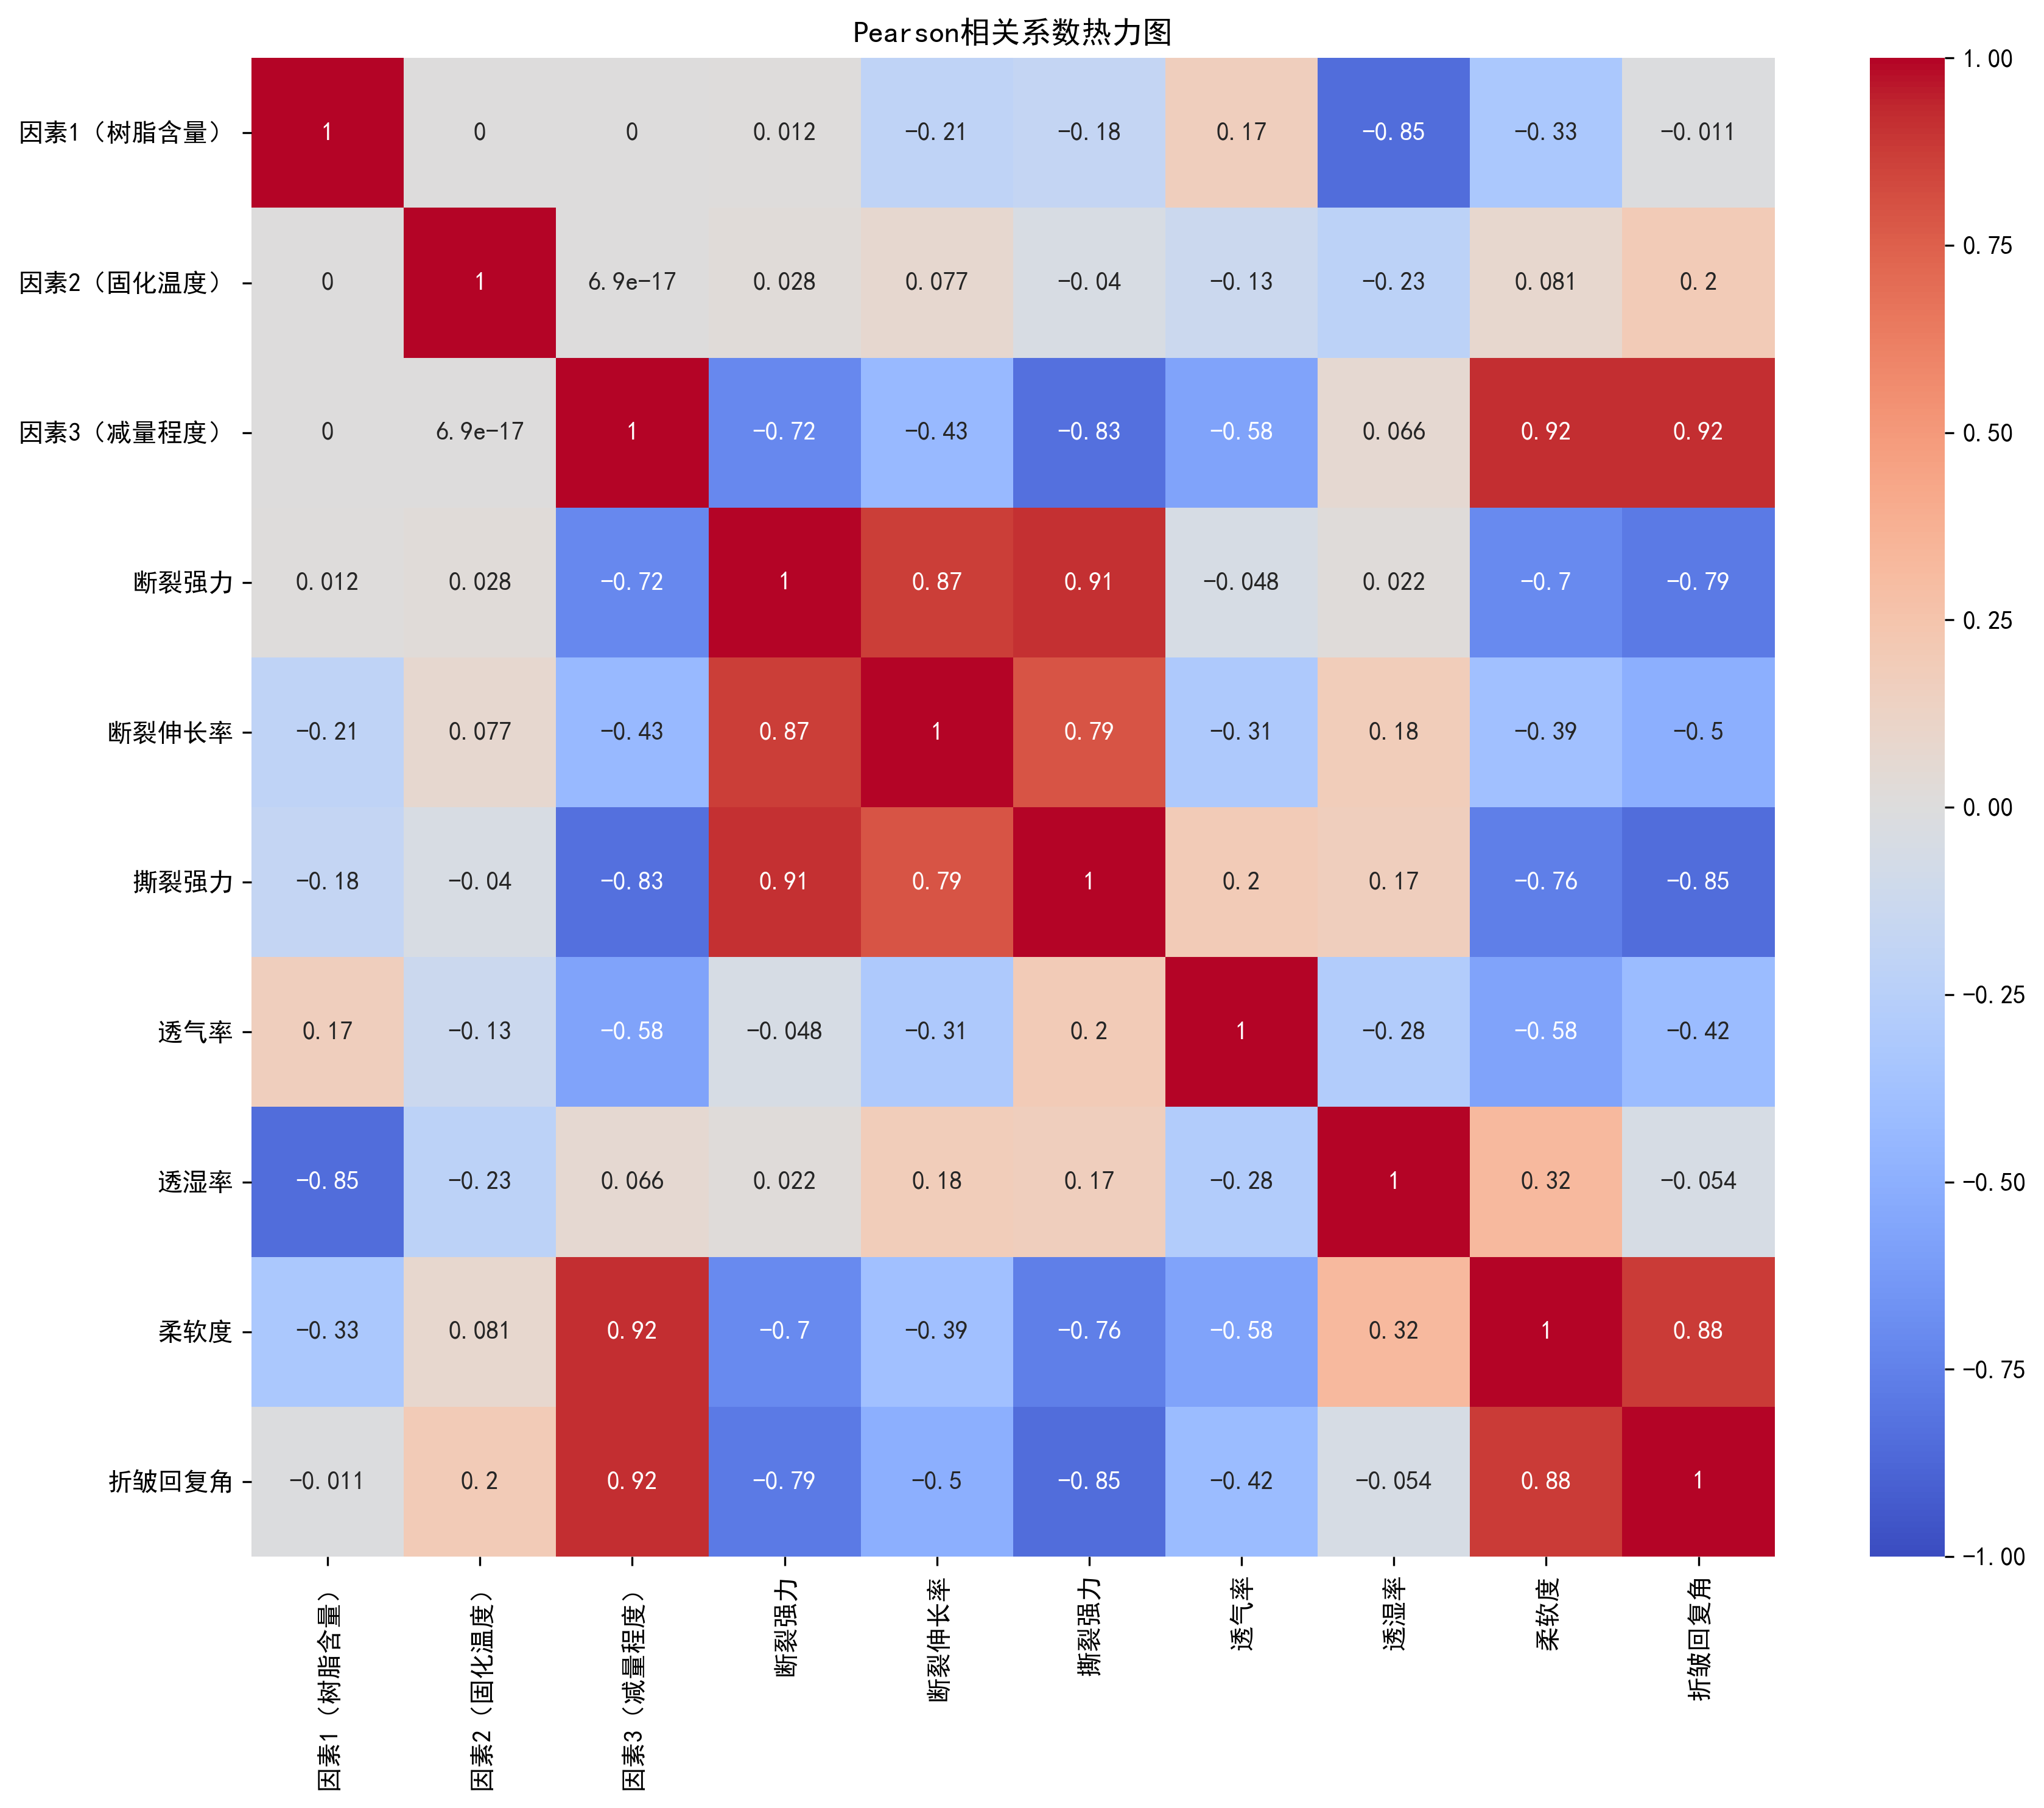

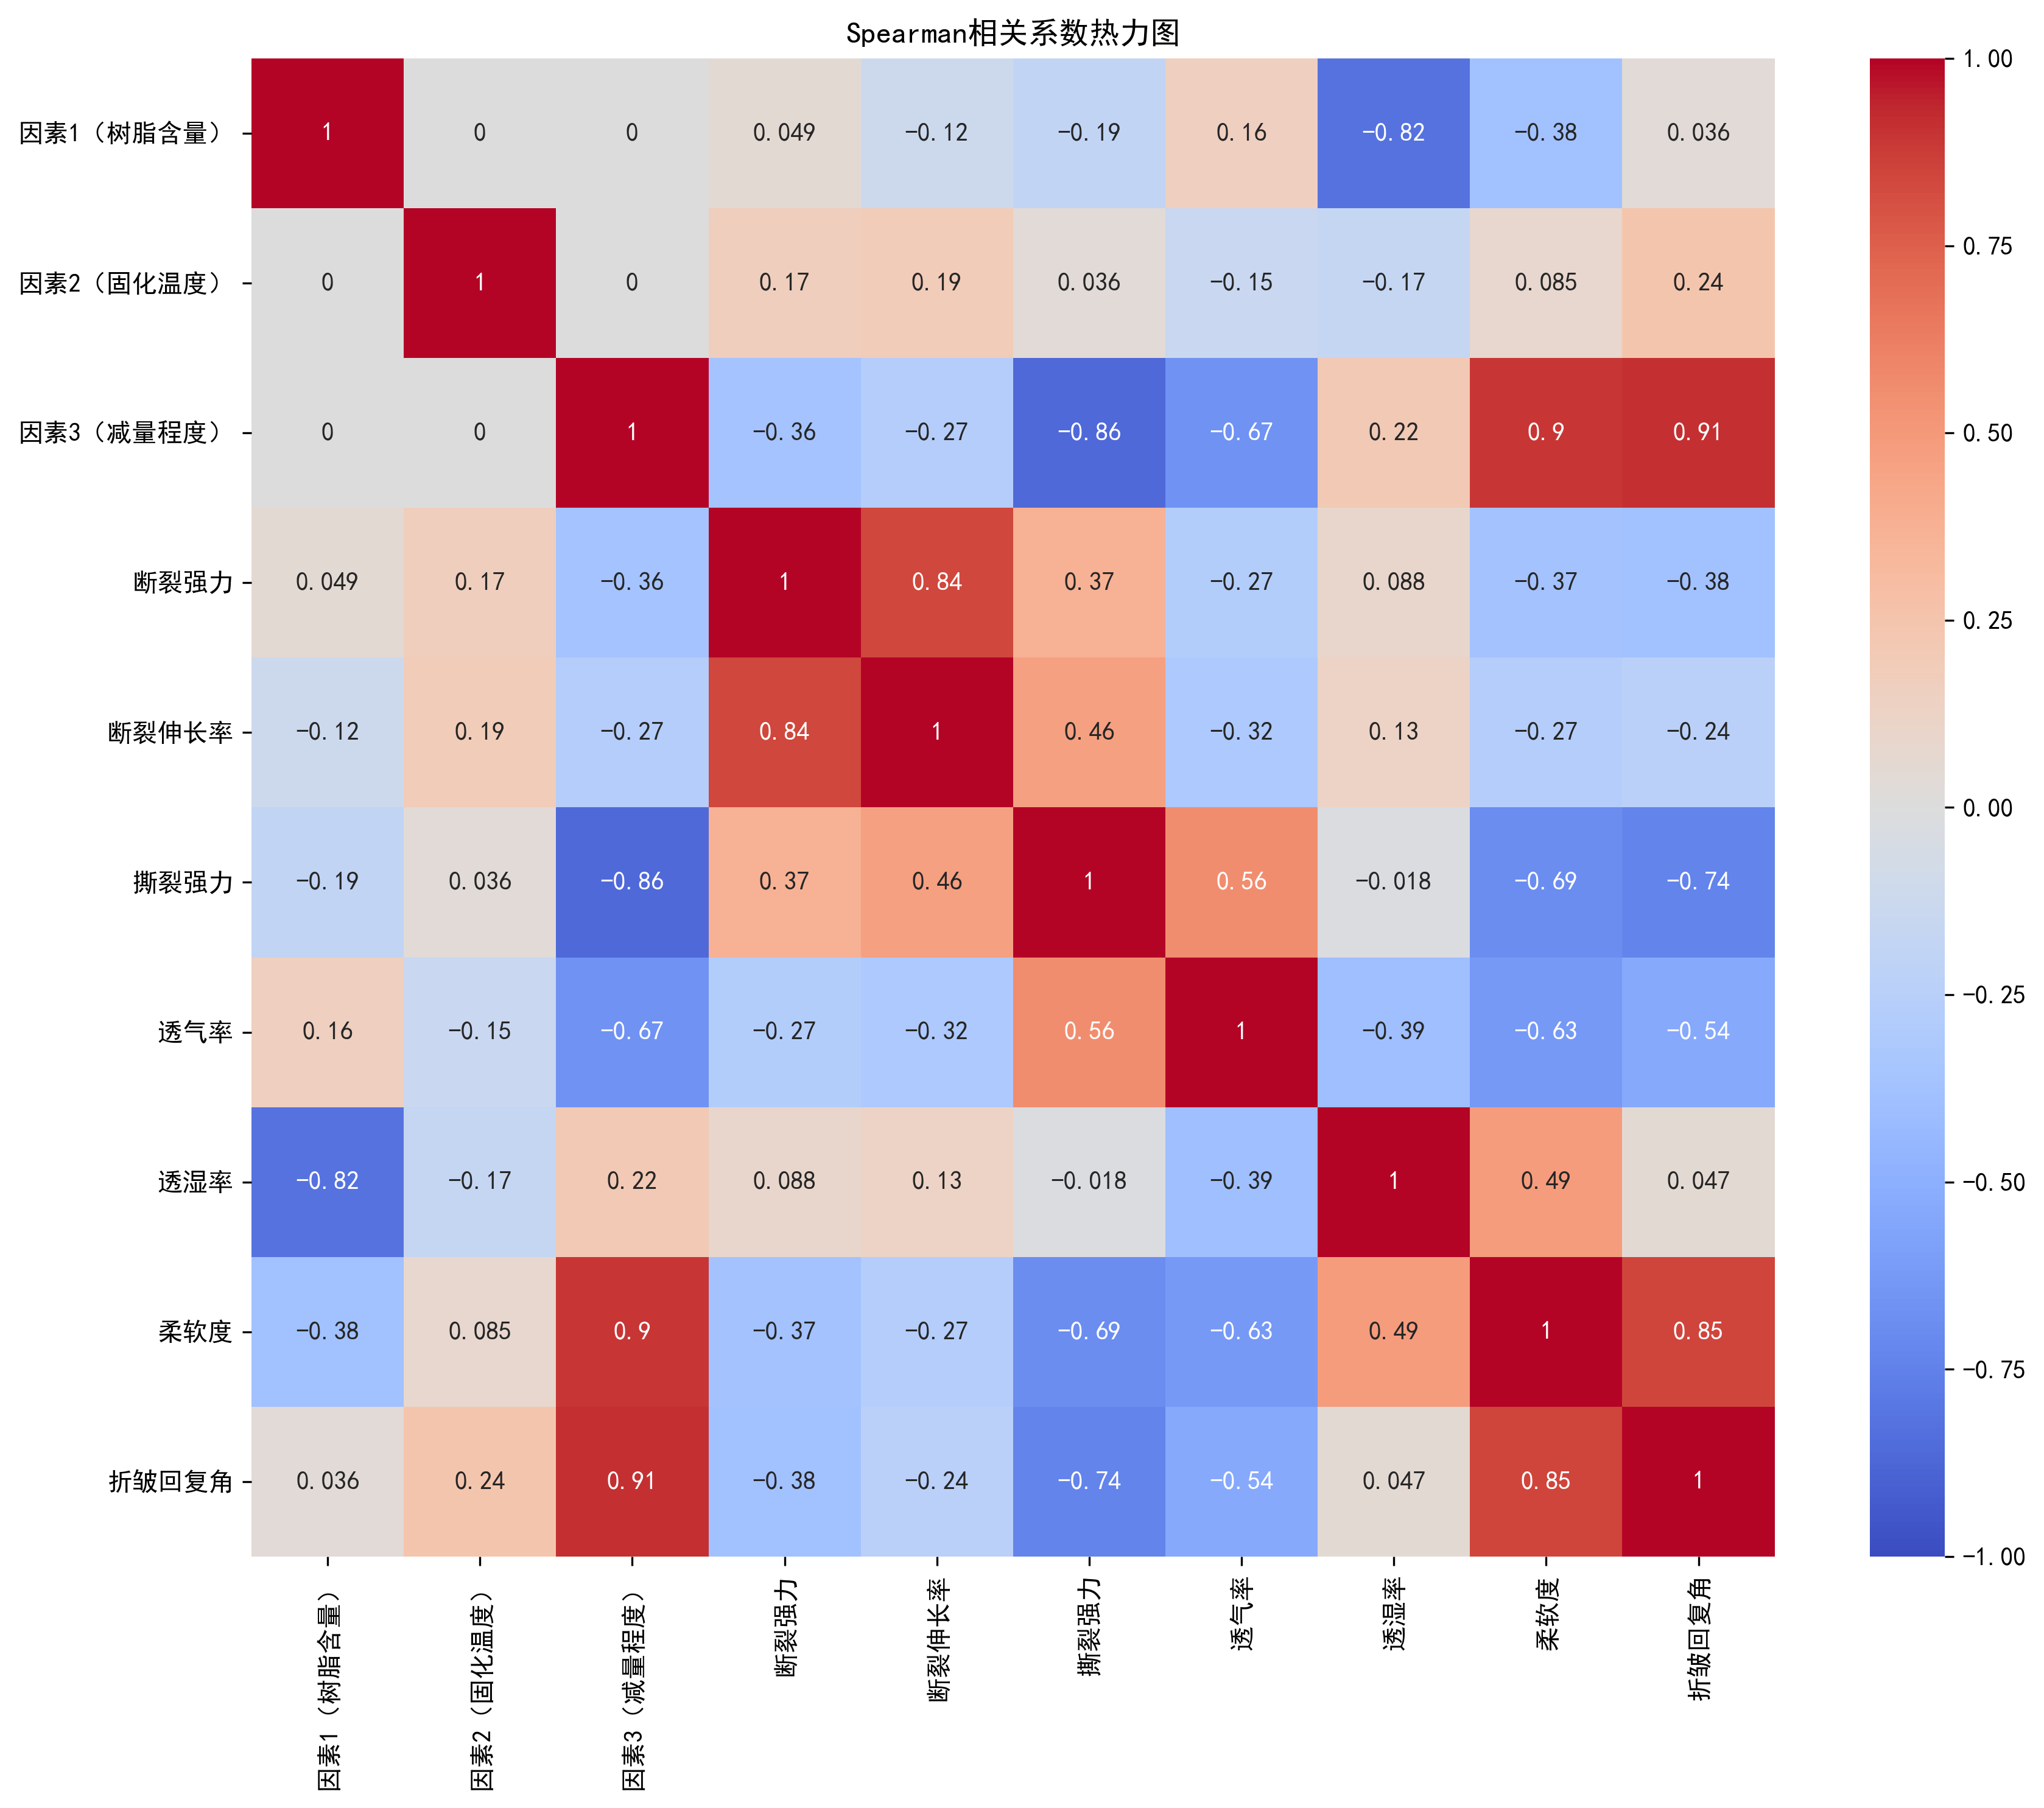


主成分分析解释方差比：
[0.57830018 0.25608898 0.12329899 0.02753839 0.00680819 0.00508859
 0.00287668]


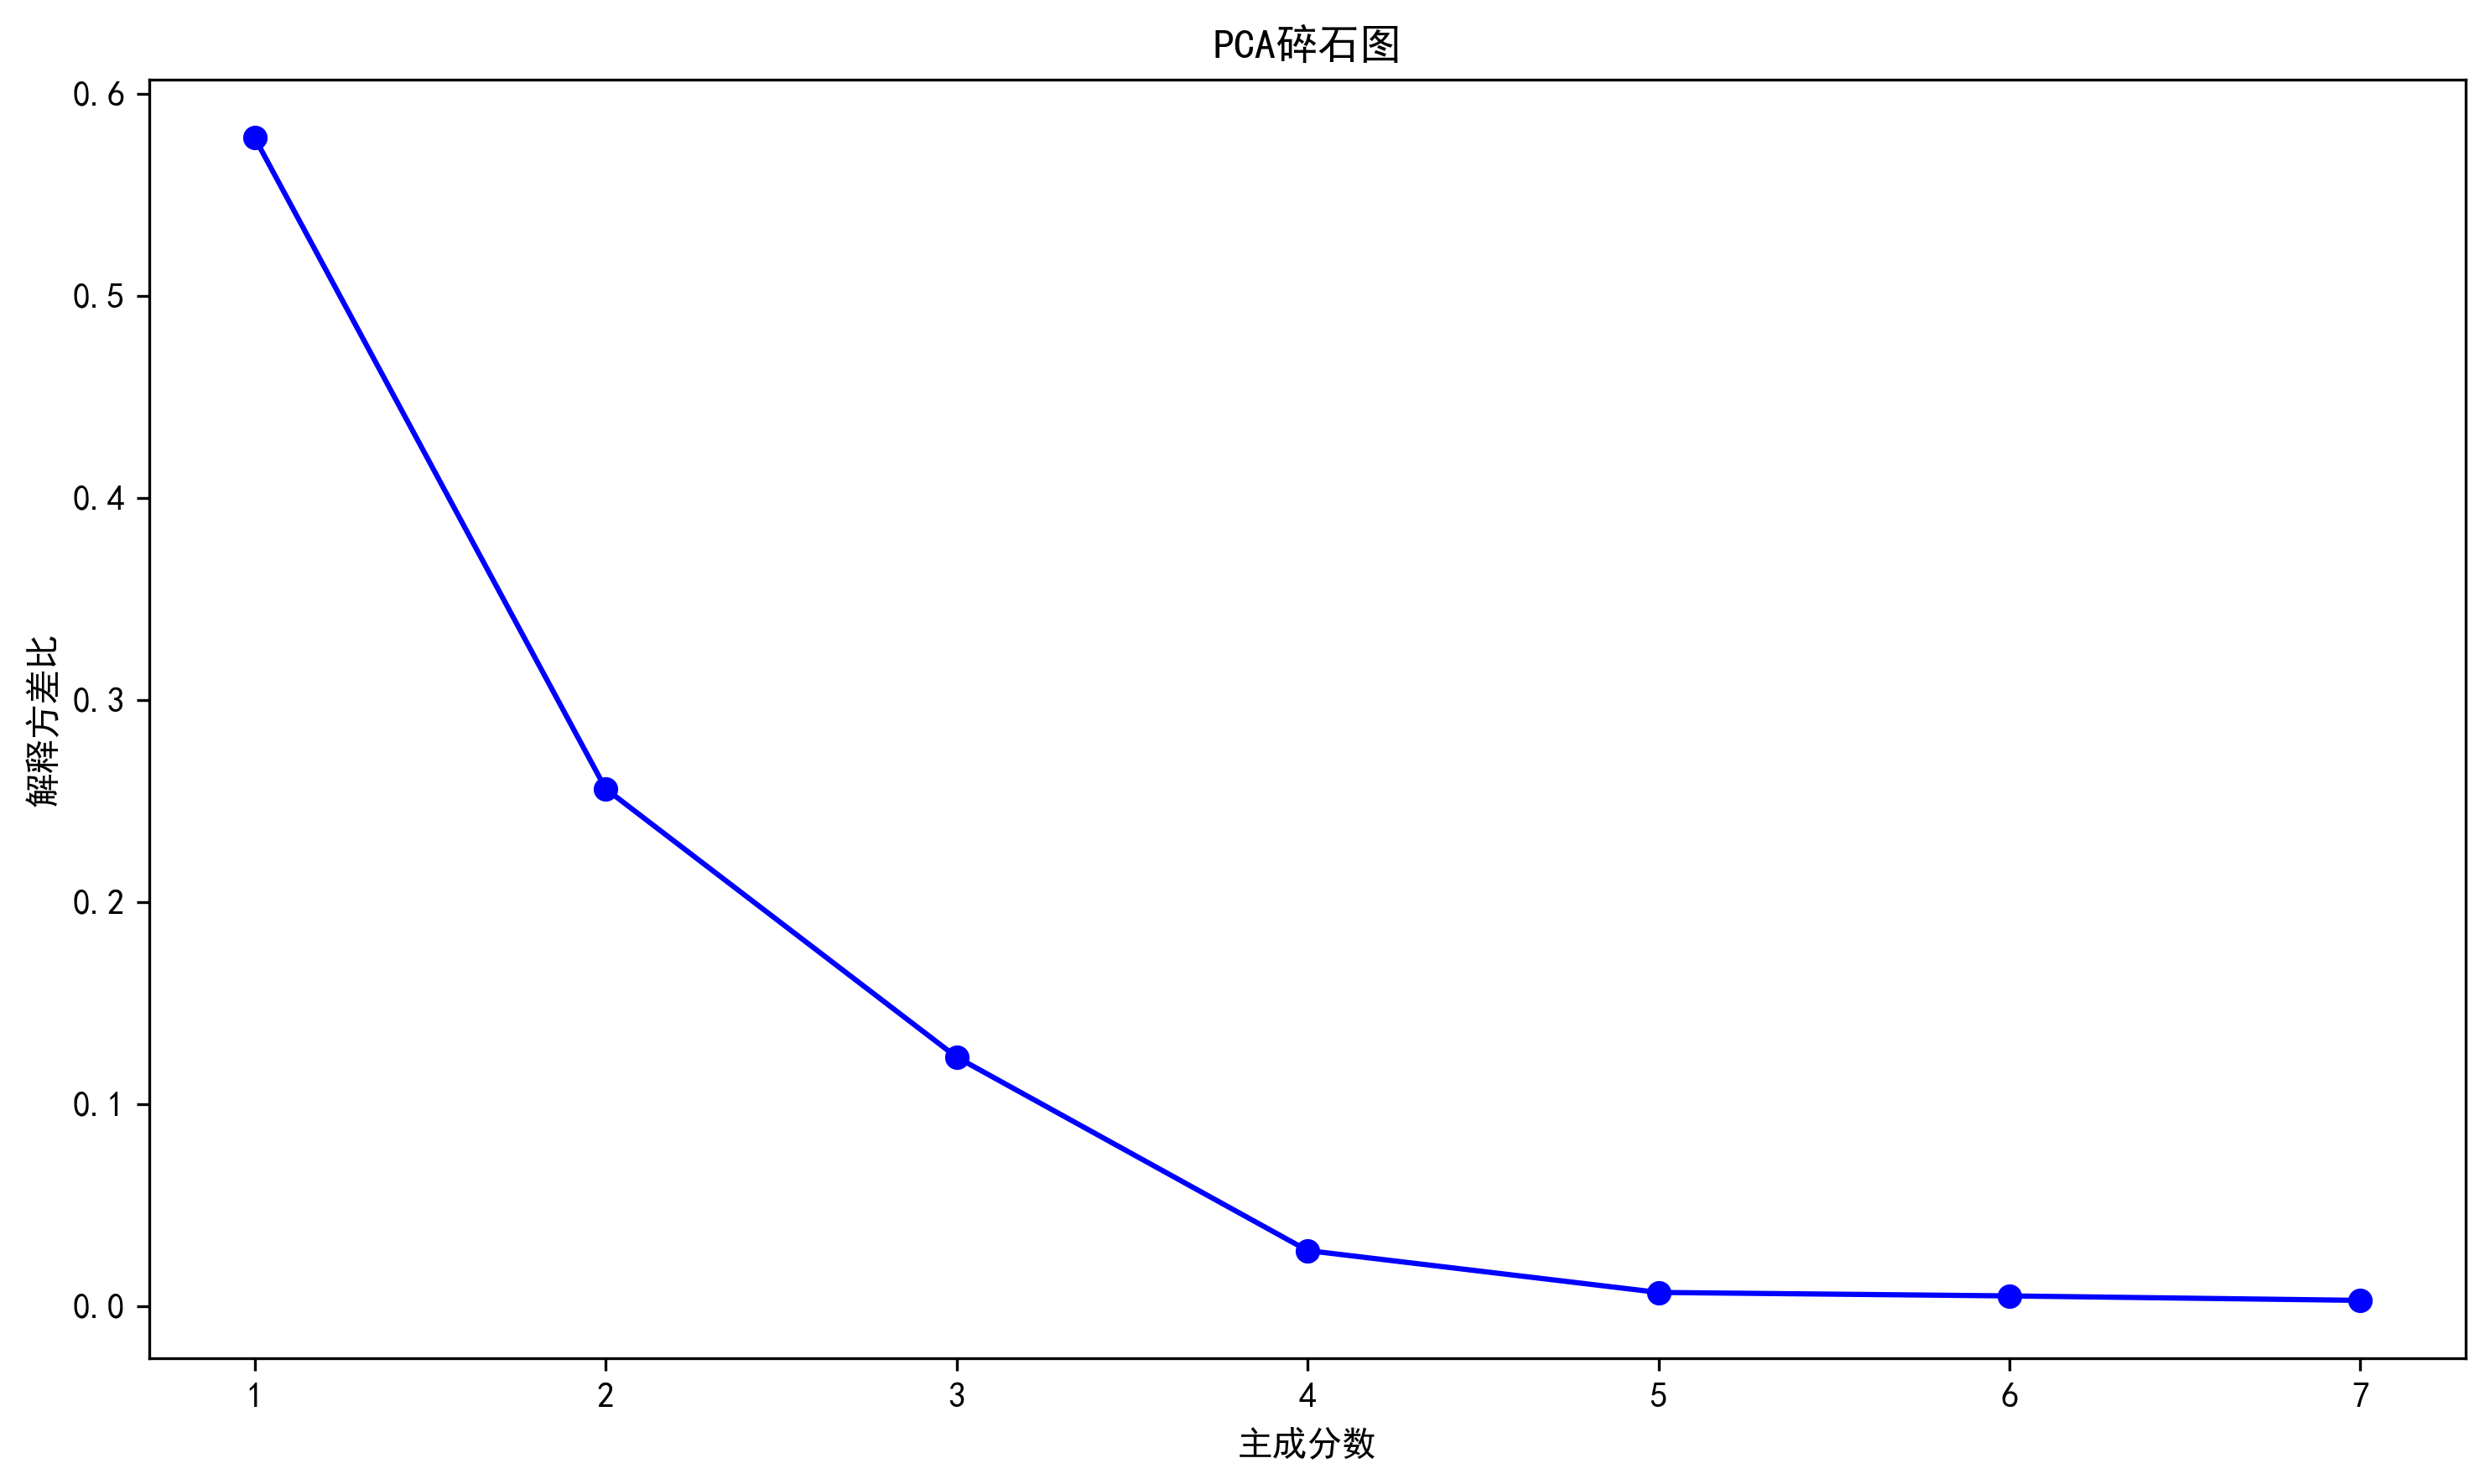

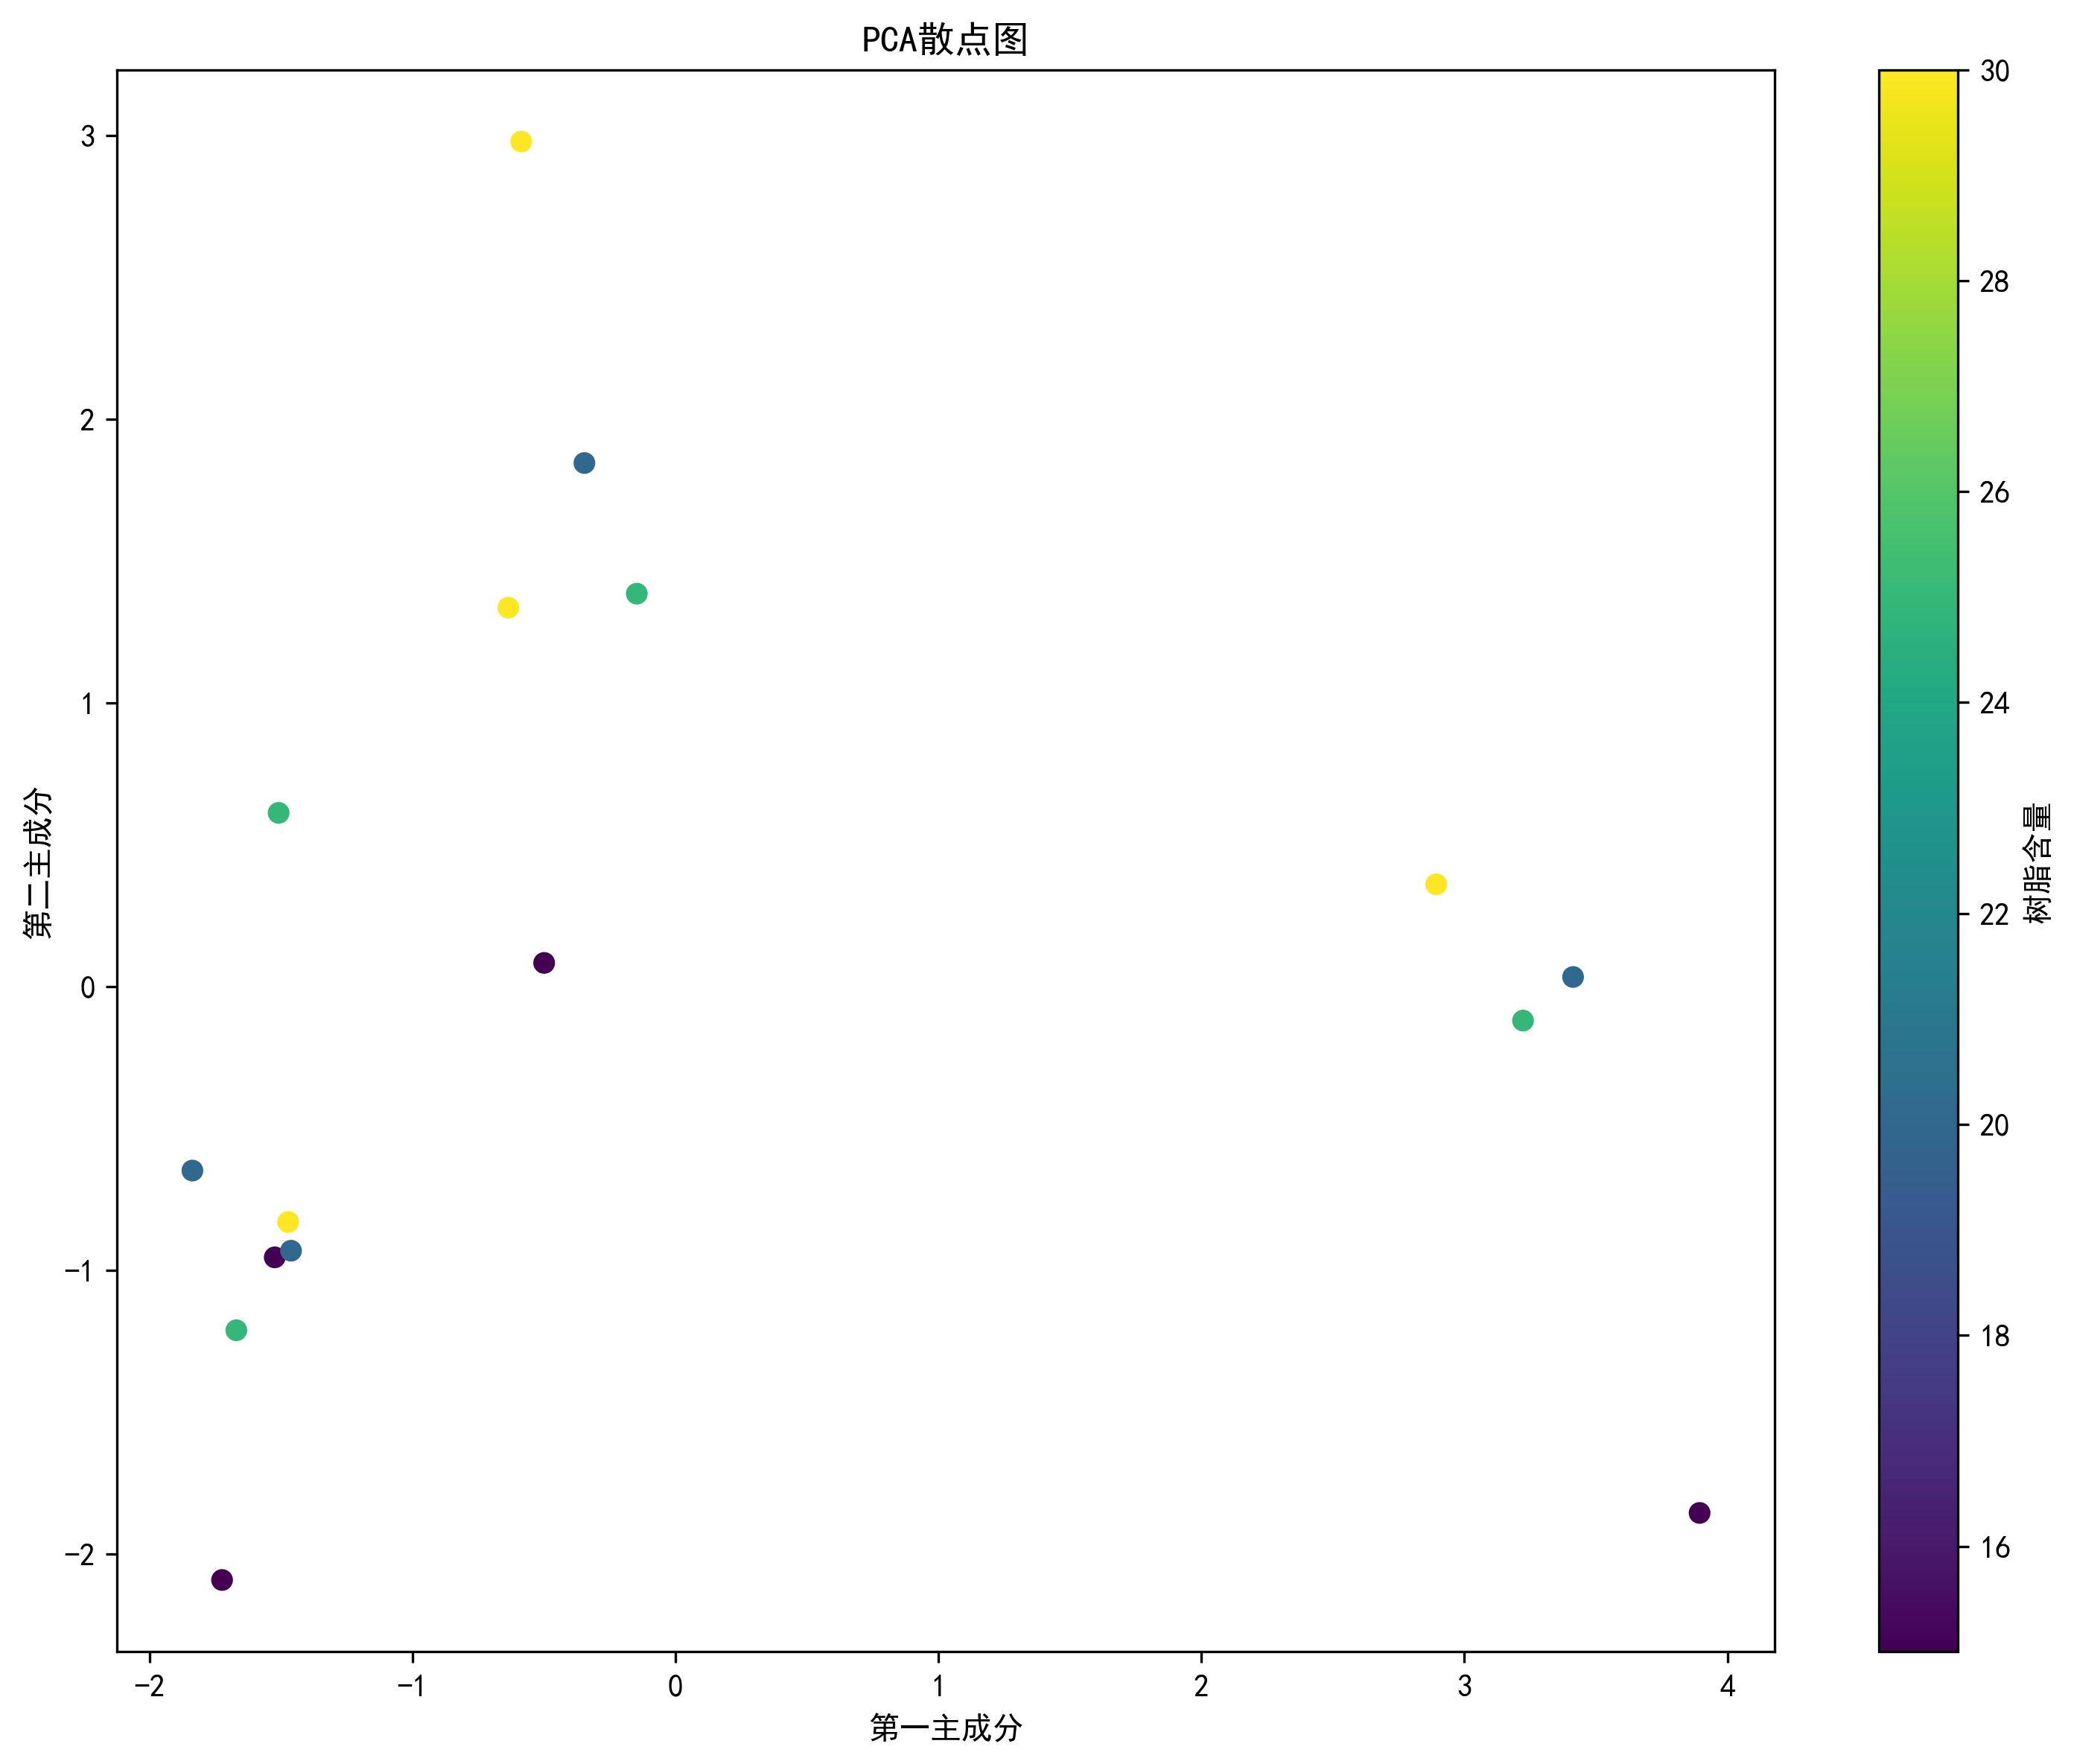


断裂强力的特征重要性：
因素1（树脂含量）    0.009104
因素2（固化温度）    0.019965
因素3（减量程度）    0.970931
dtype: float64

断裂伸长率的特征重要性：
因素1（树脂含量）    0.088688
因素2（固化温度）    0.085638
因素3（减量程度）    0.825675
dtype: float64

撕裂强力的特征重要性：
因素1（树脂含量）    0.041670
因素2（固化温度）    0.051161
因素3（减量程度）    0.907169
dtype: float64

透气率的特征重要性：
因素1（树脂含量）    0.130990
因素2（固化温度）    0.137607
因素3（减量程度）    0.731403
dtype: float64

透湿率的特征重要性：
因素1（树脂含量）    0.768117
因素2（固化温度）    0.088910
因素3（减量程度）    0.142973
dtype: float64

柔软度的特征重要性：
因素1（树脂含量）    0.088568
因素2（固化温度）    0.081094
因素3（减量程度）    0.830337
dtype: float64

折皱回复角的特征重要性：
因素1（树脂含量）    0.048627
因素2（固化温度）    0.064842
因素3（减量程度）    0.886531
dtype: float64


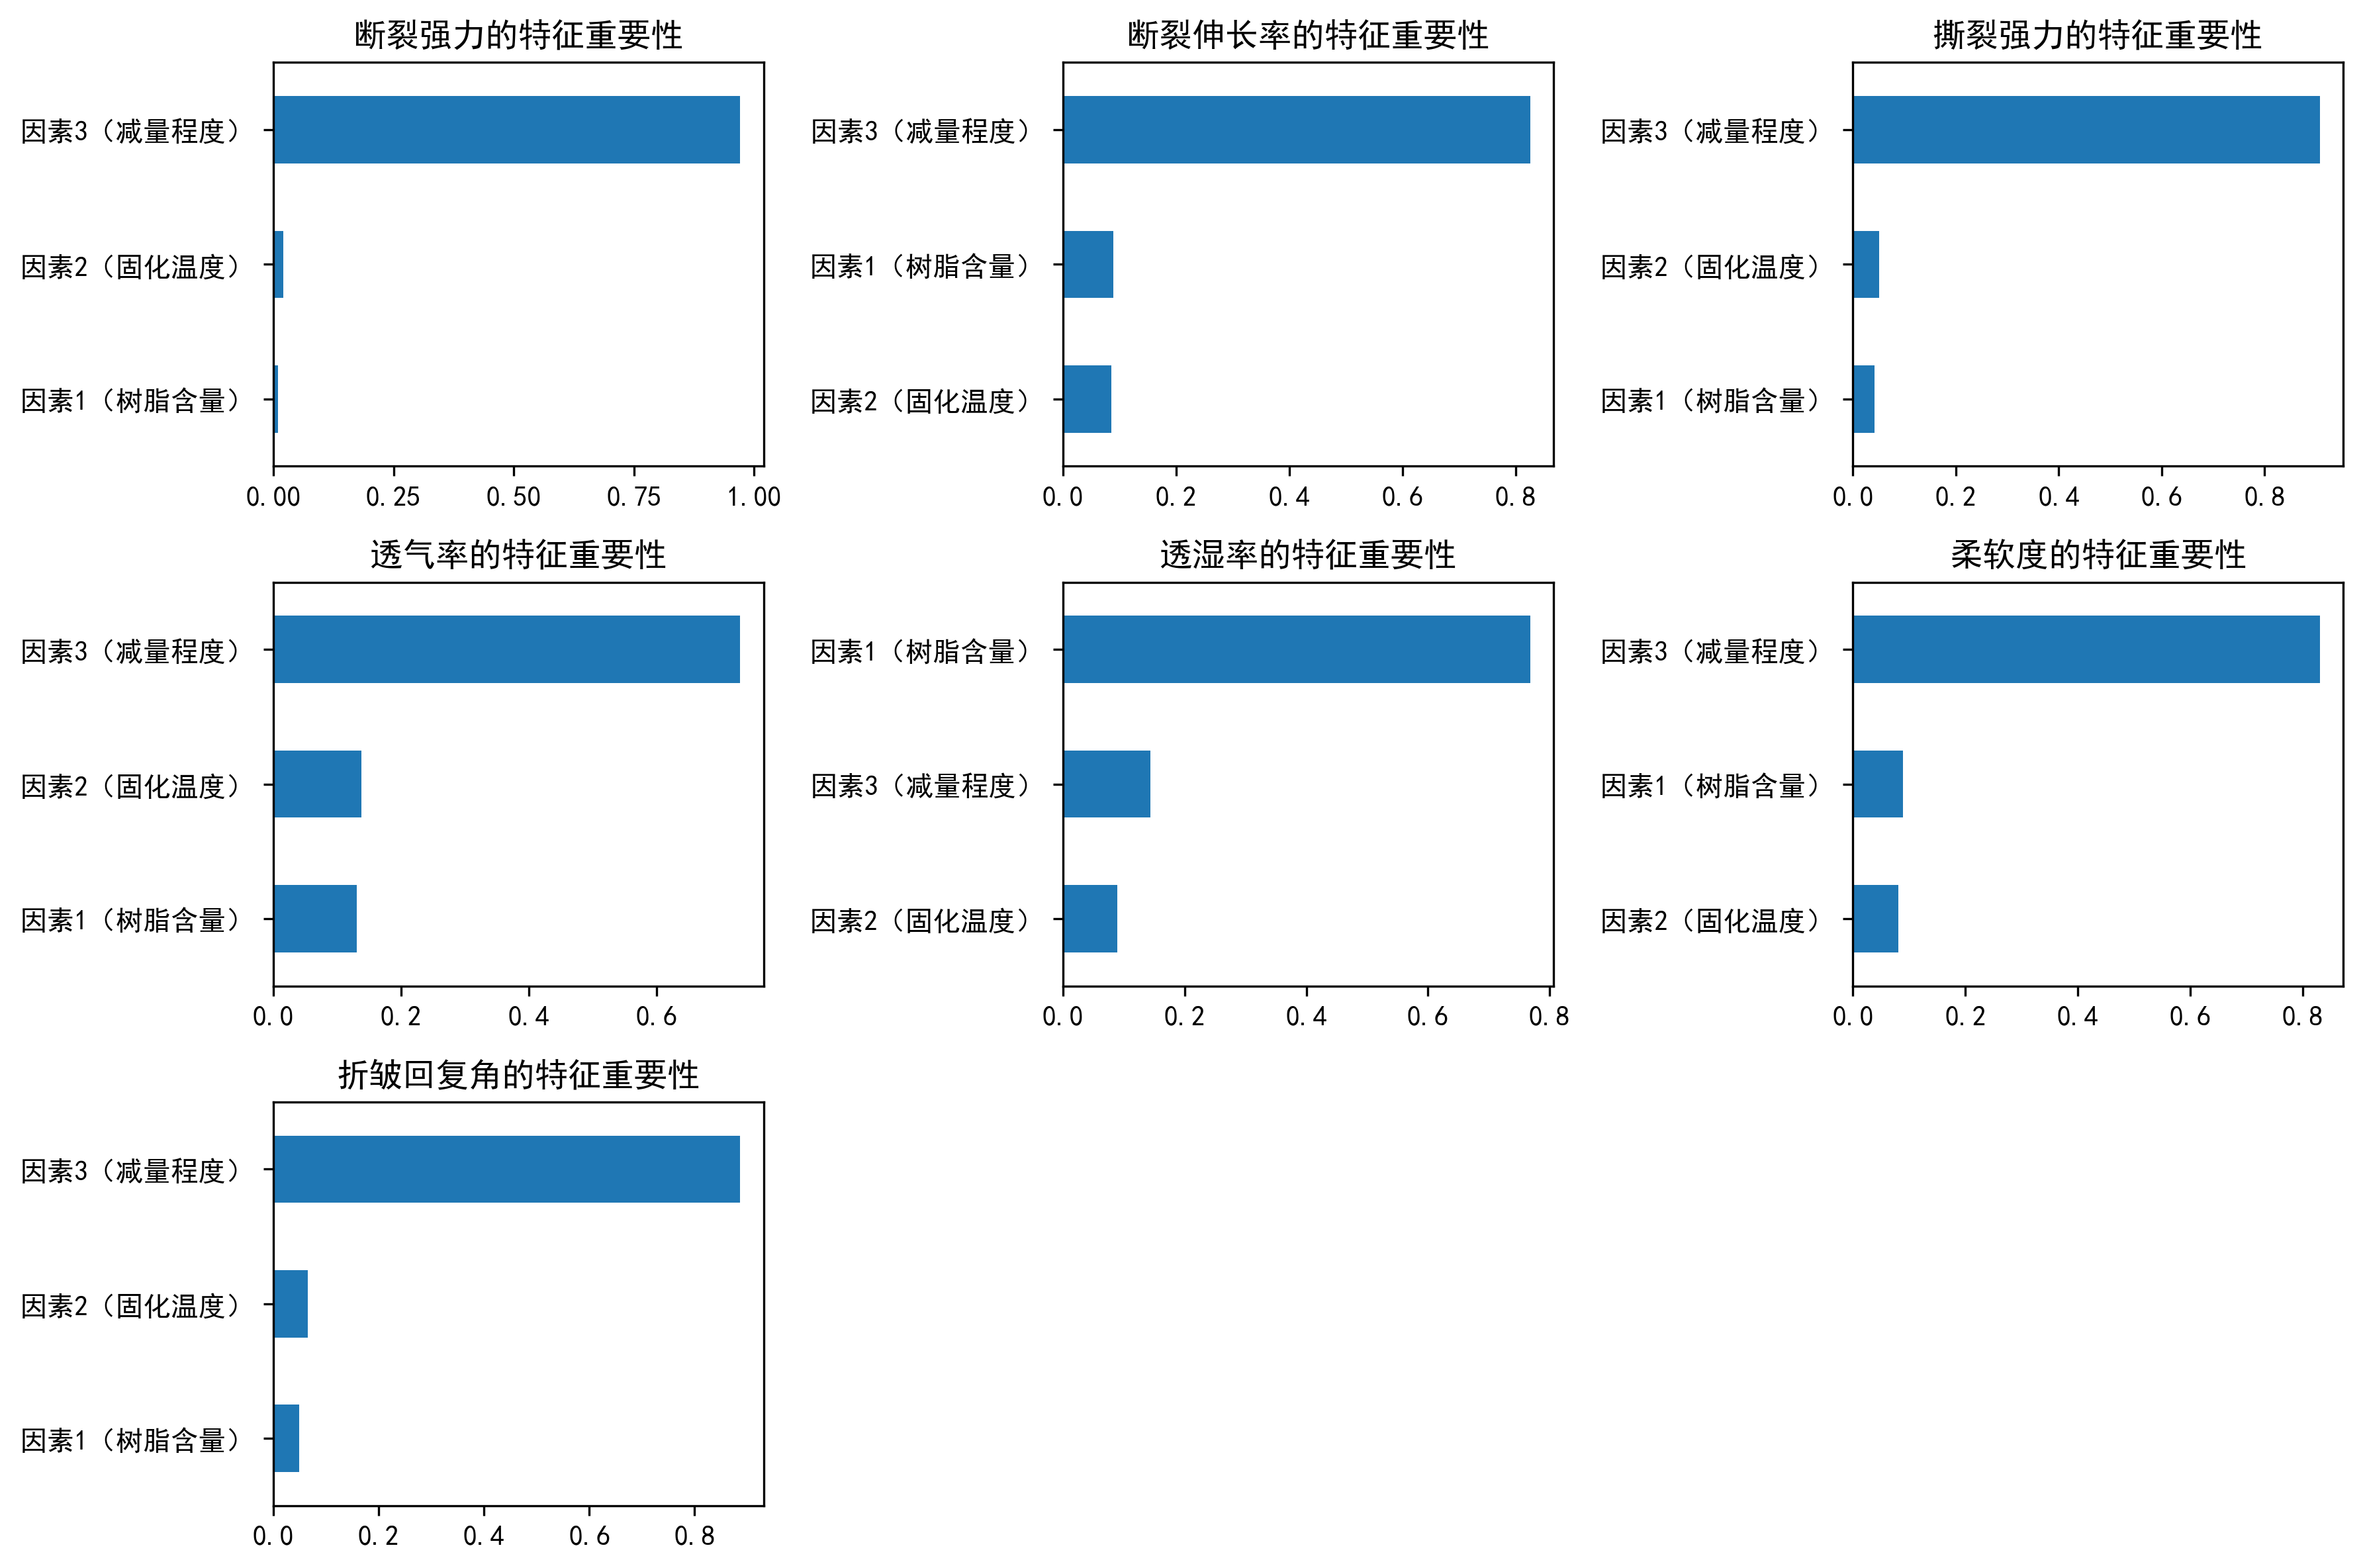

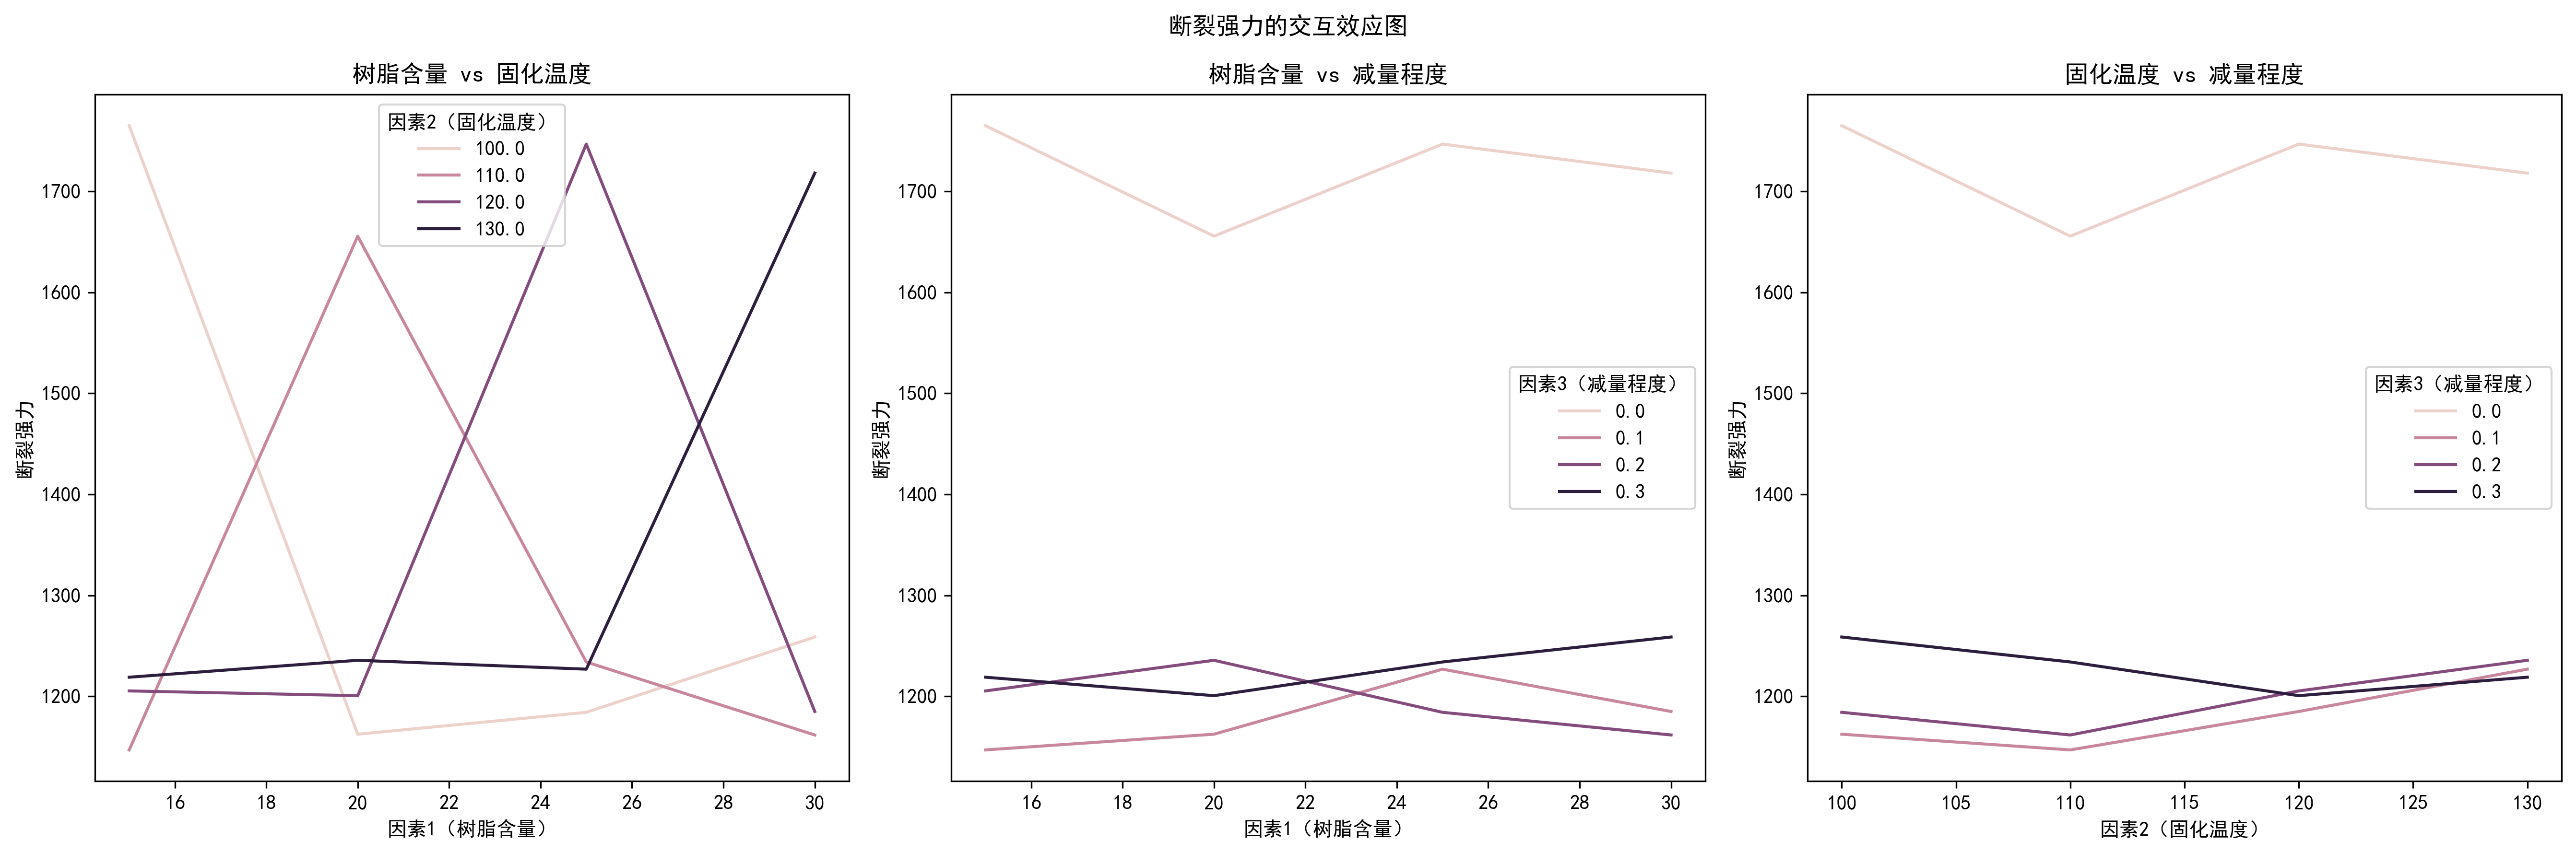

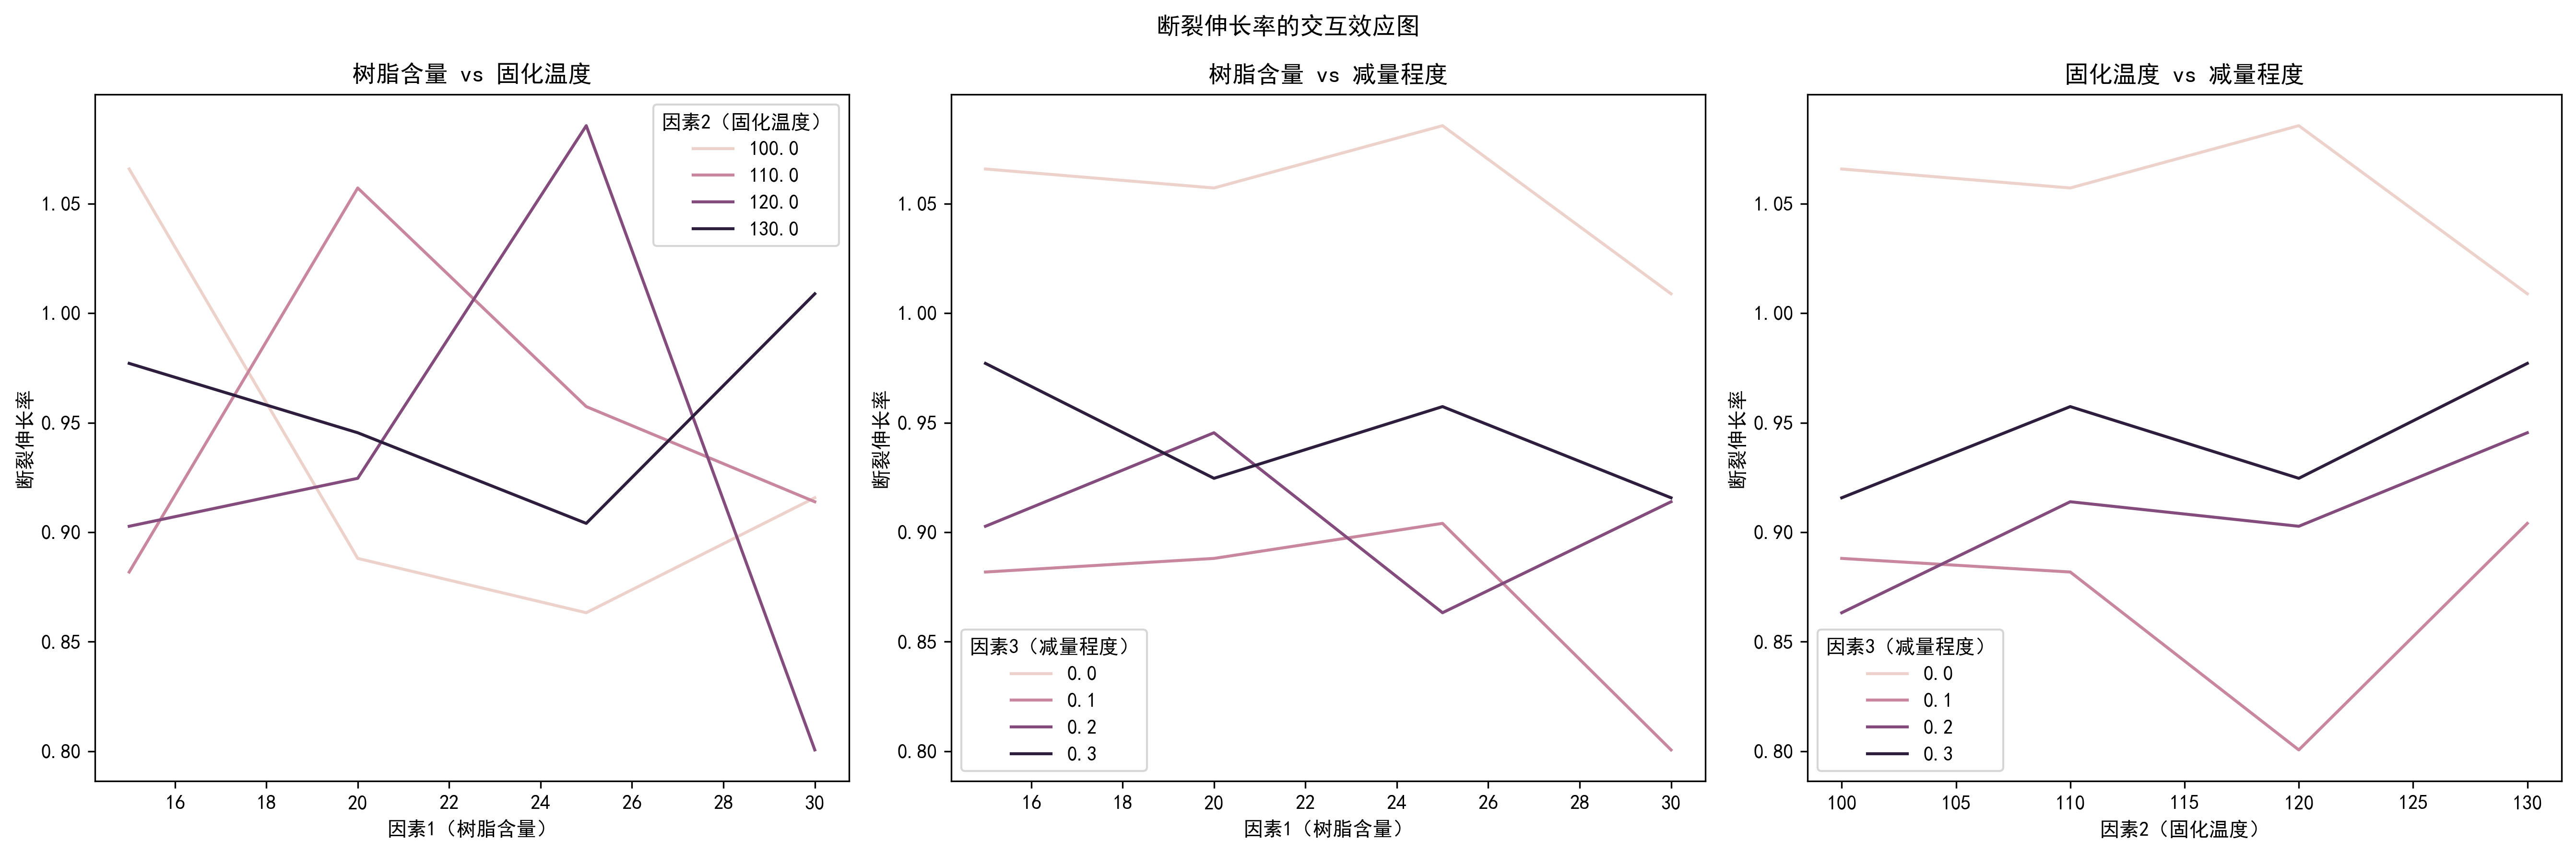

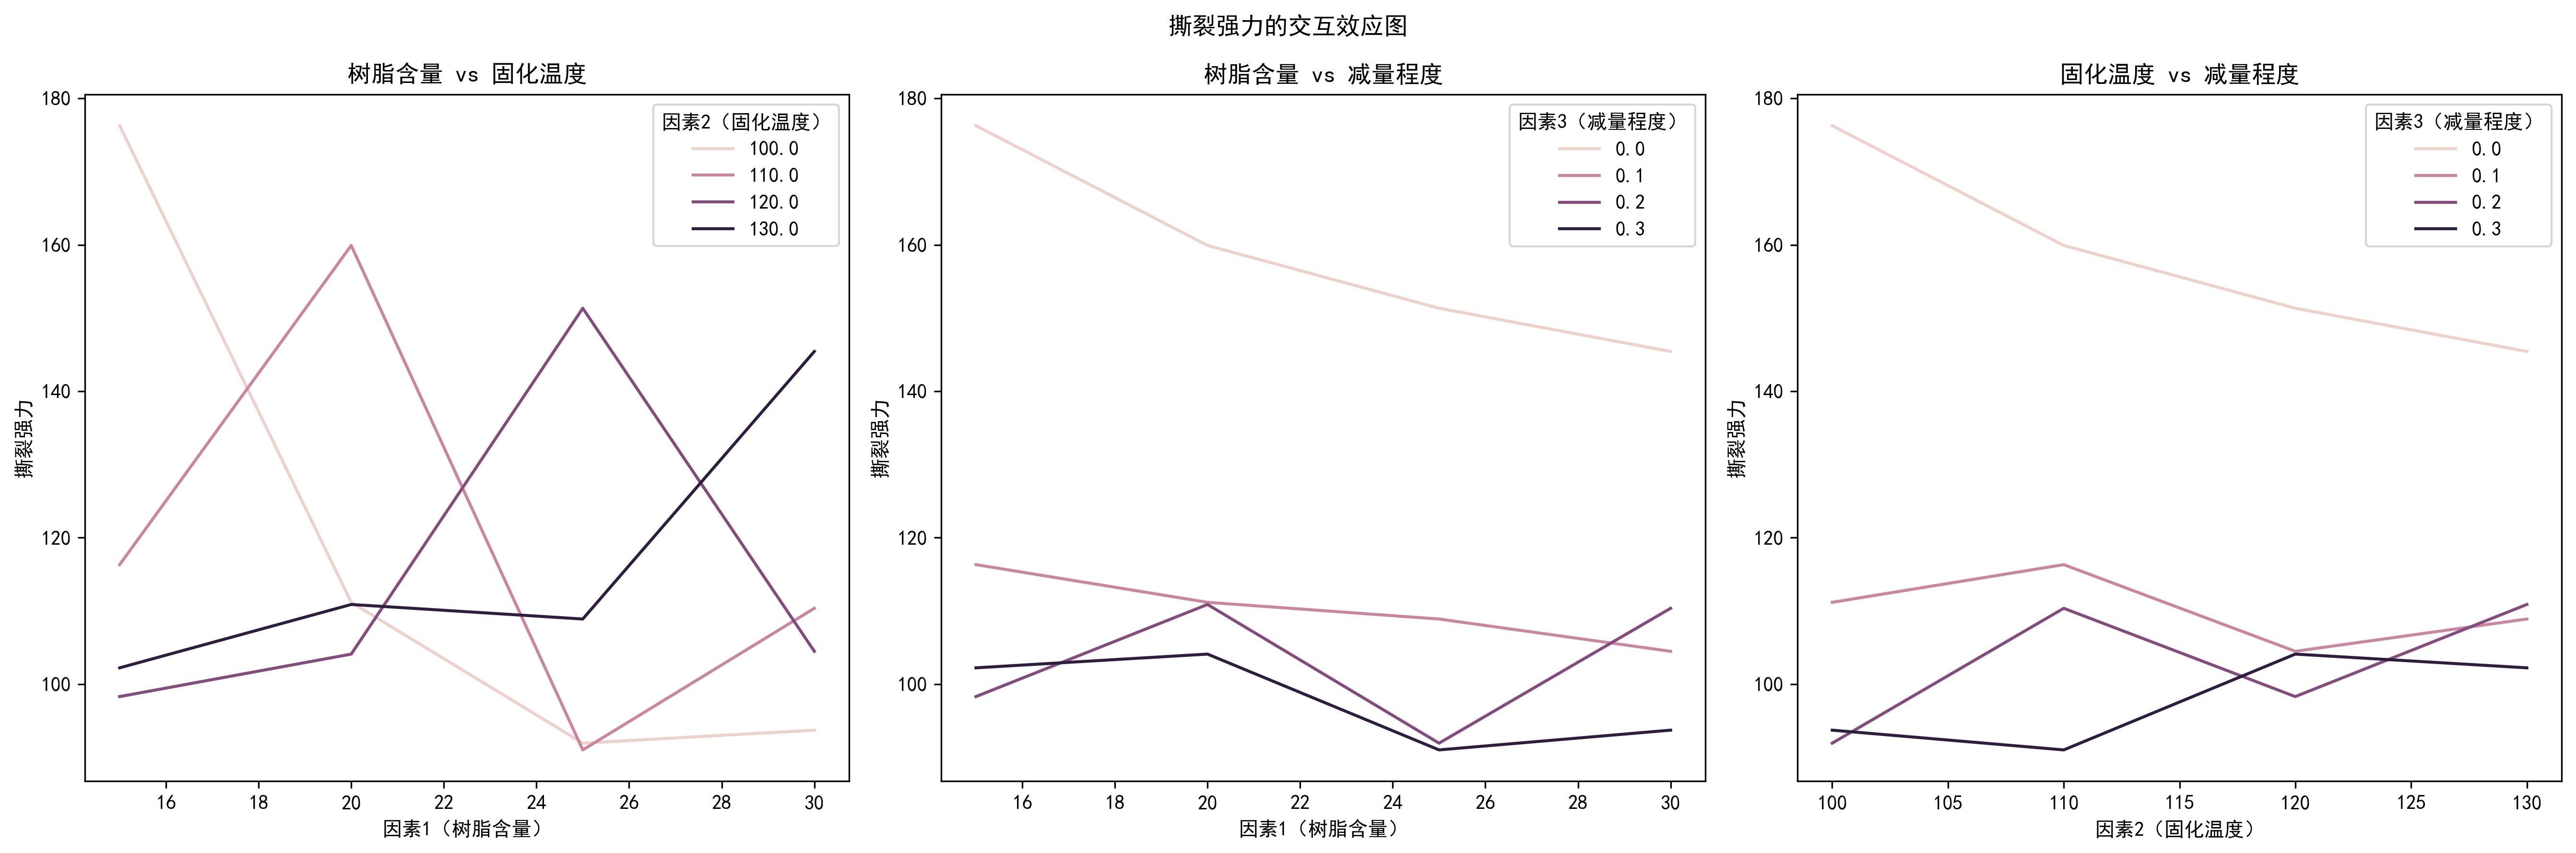

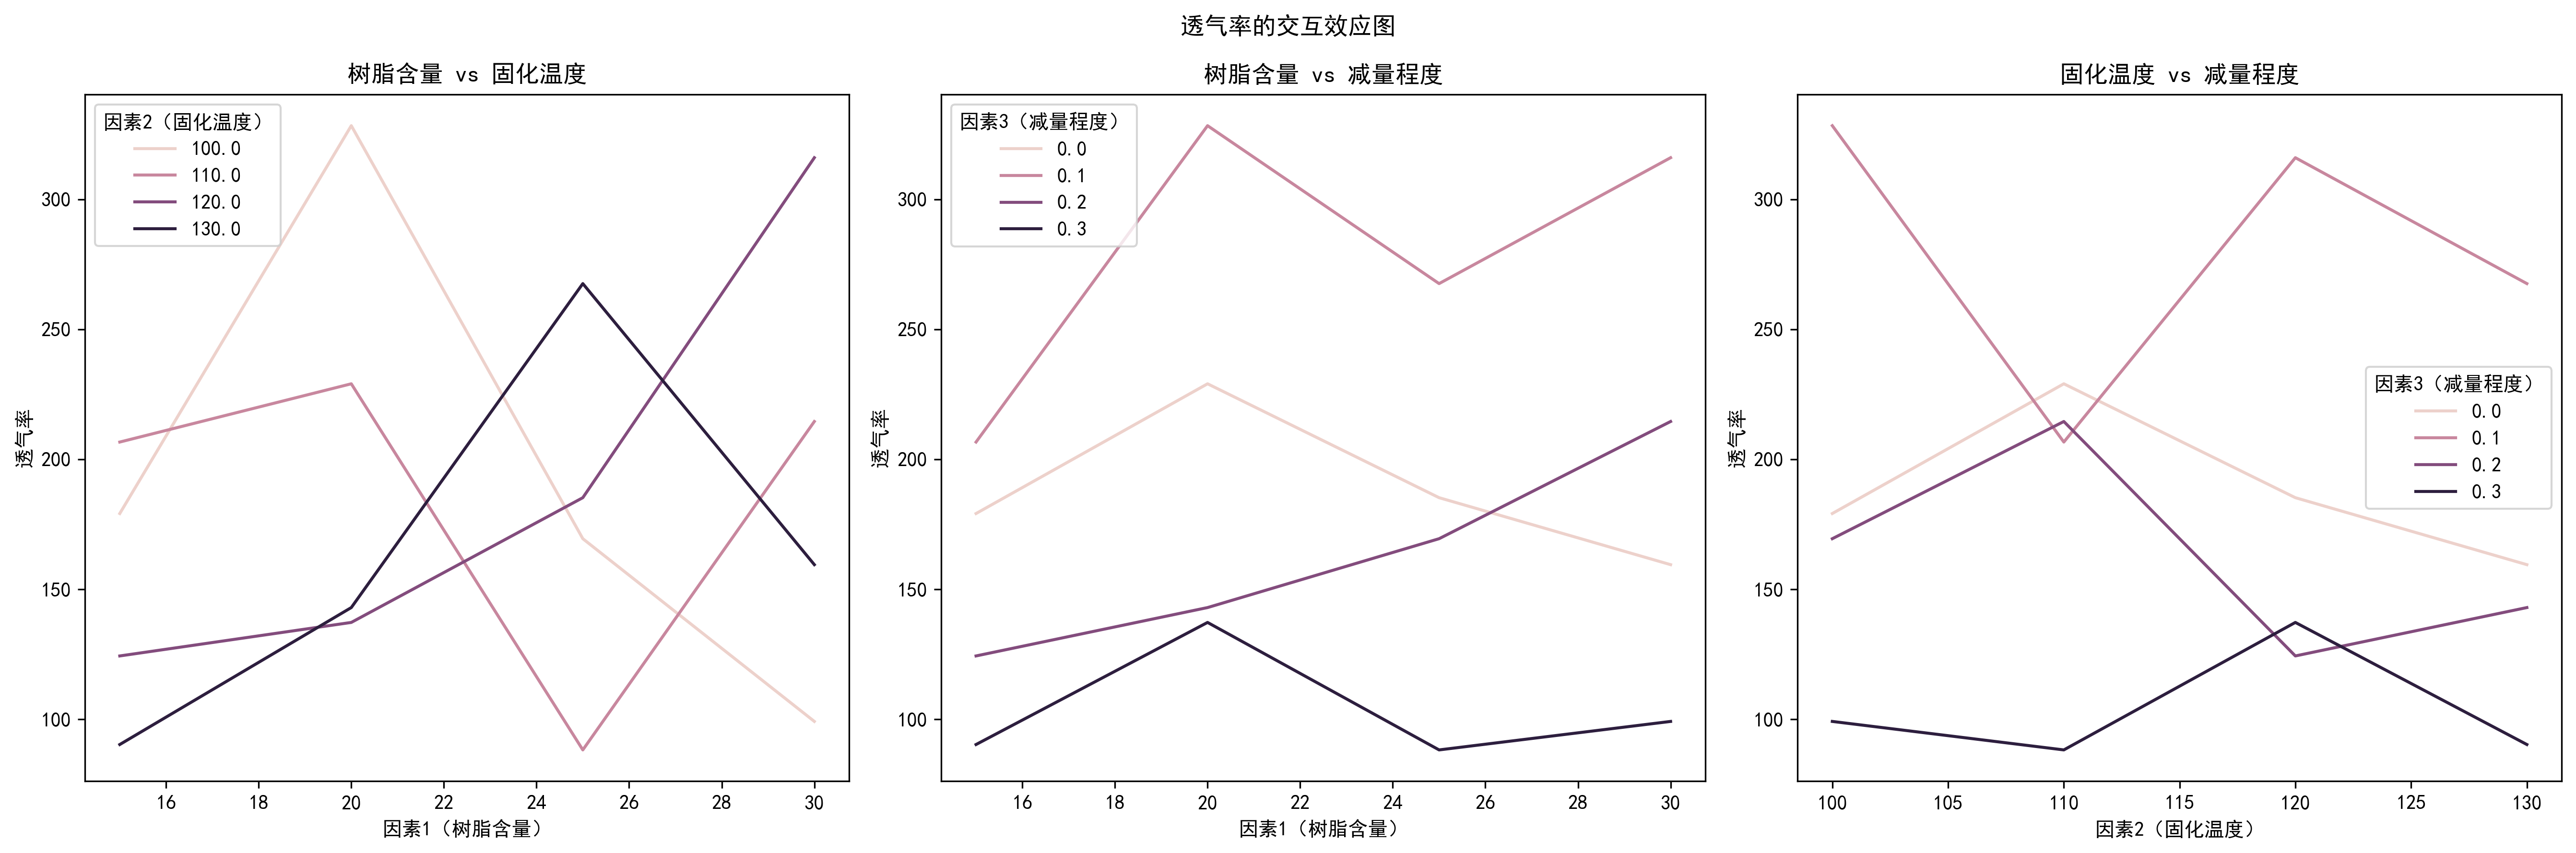

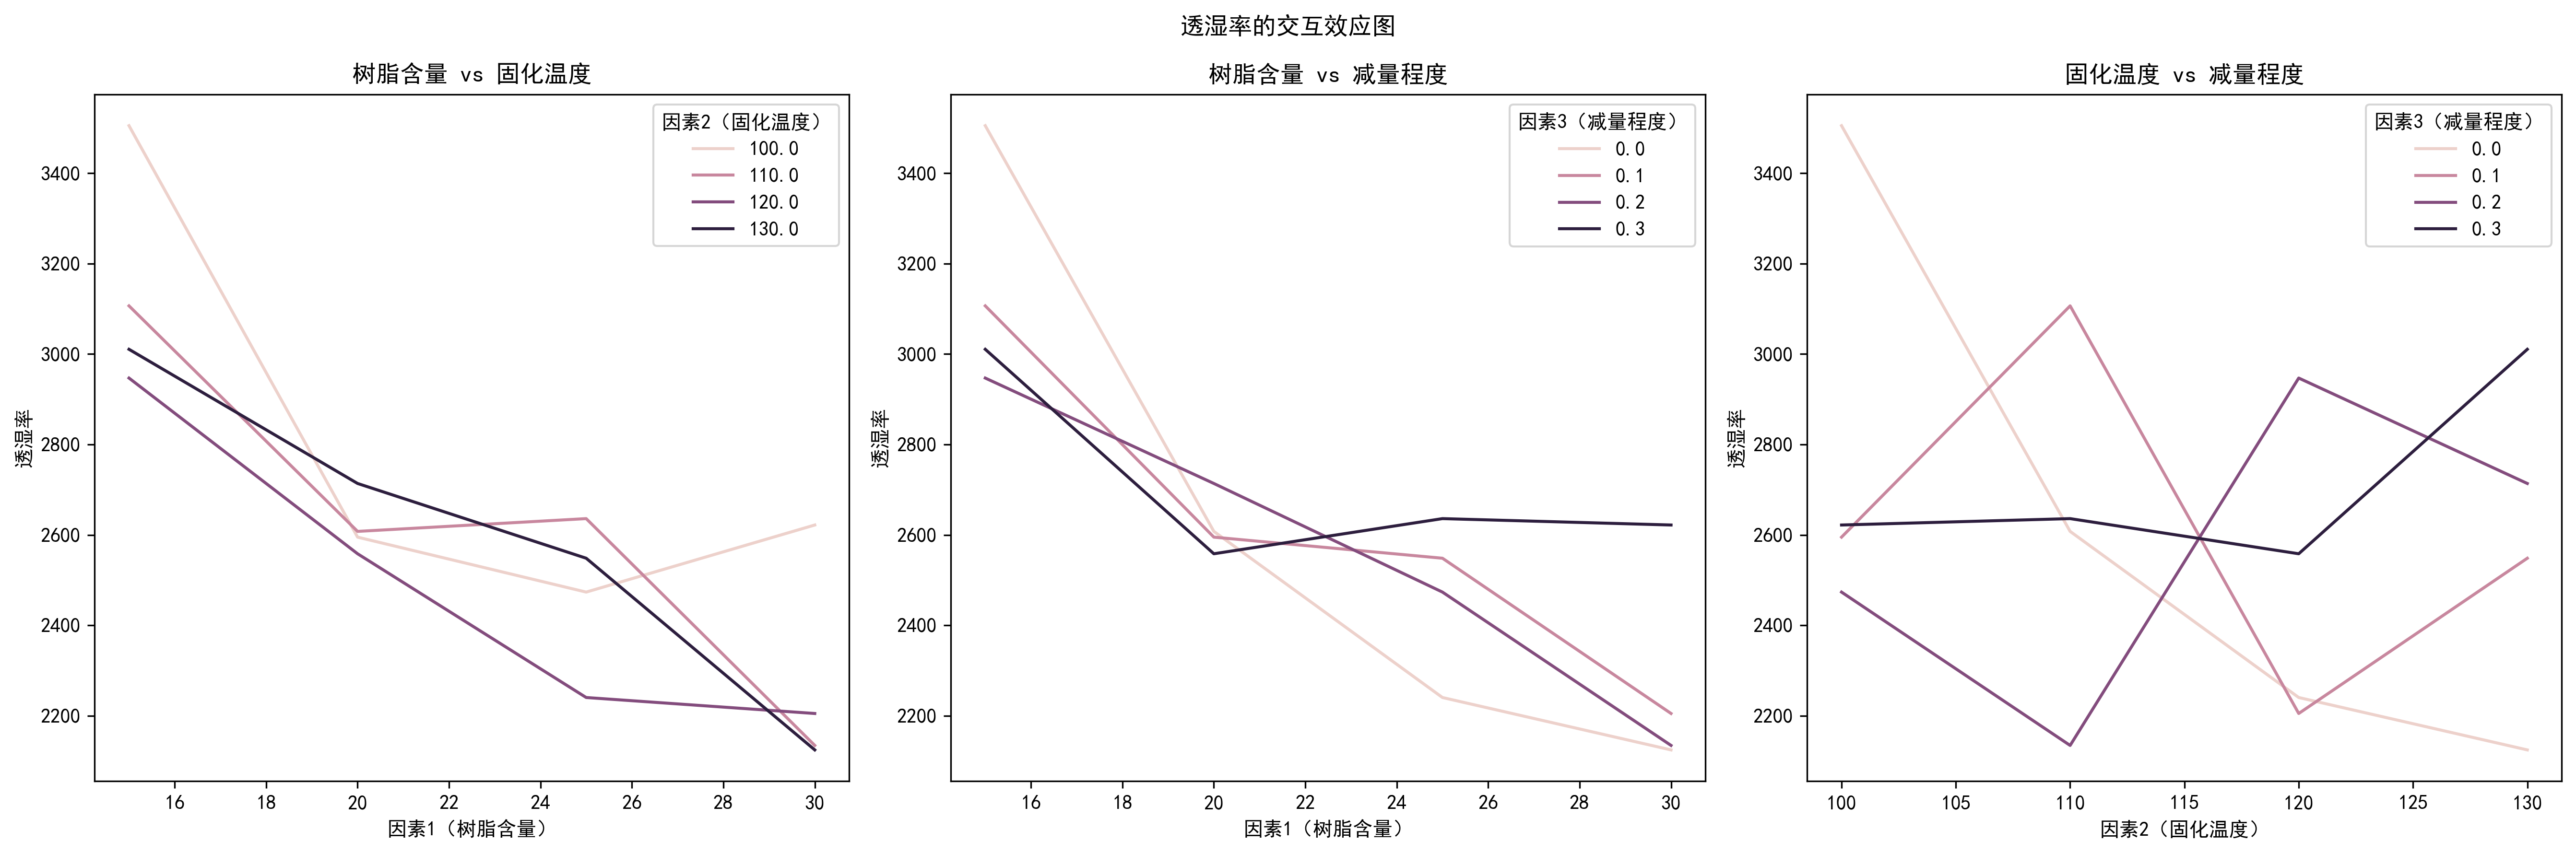

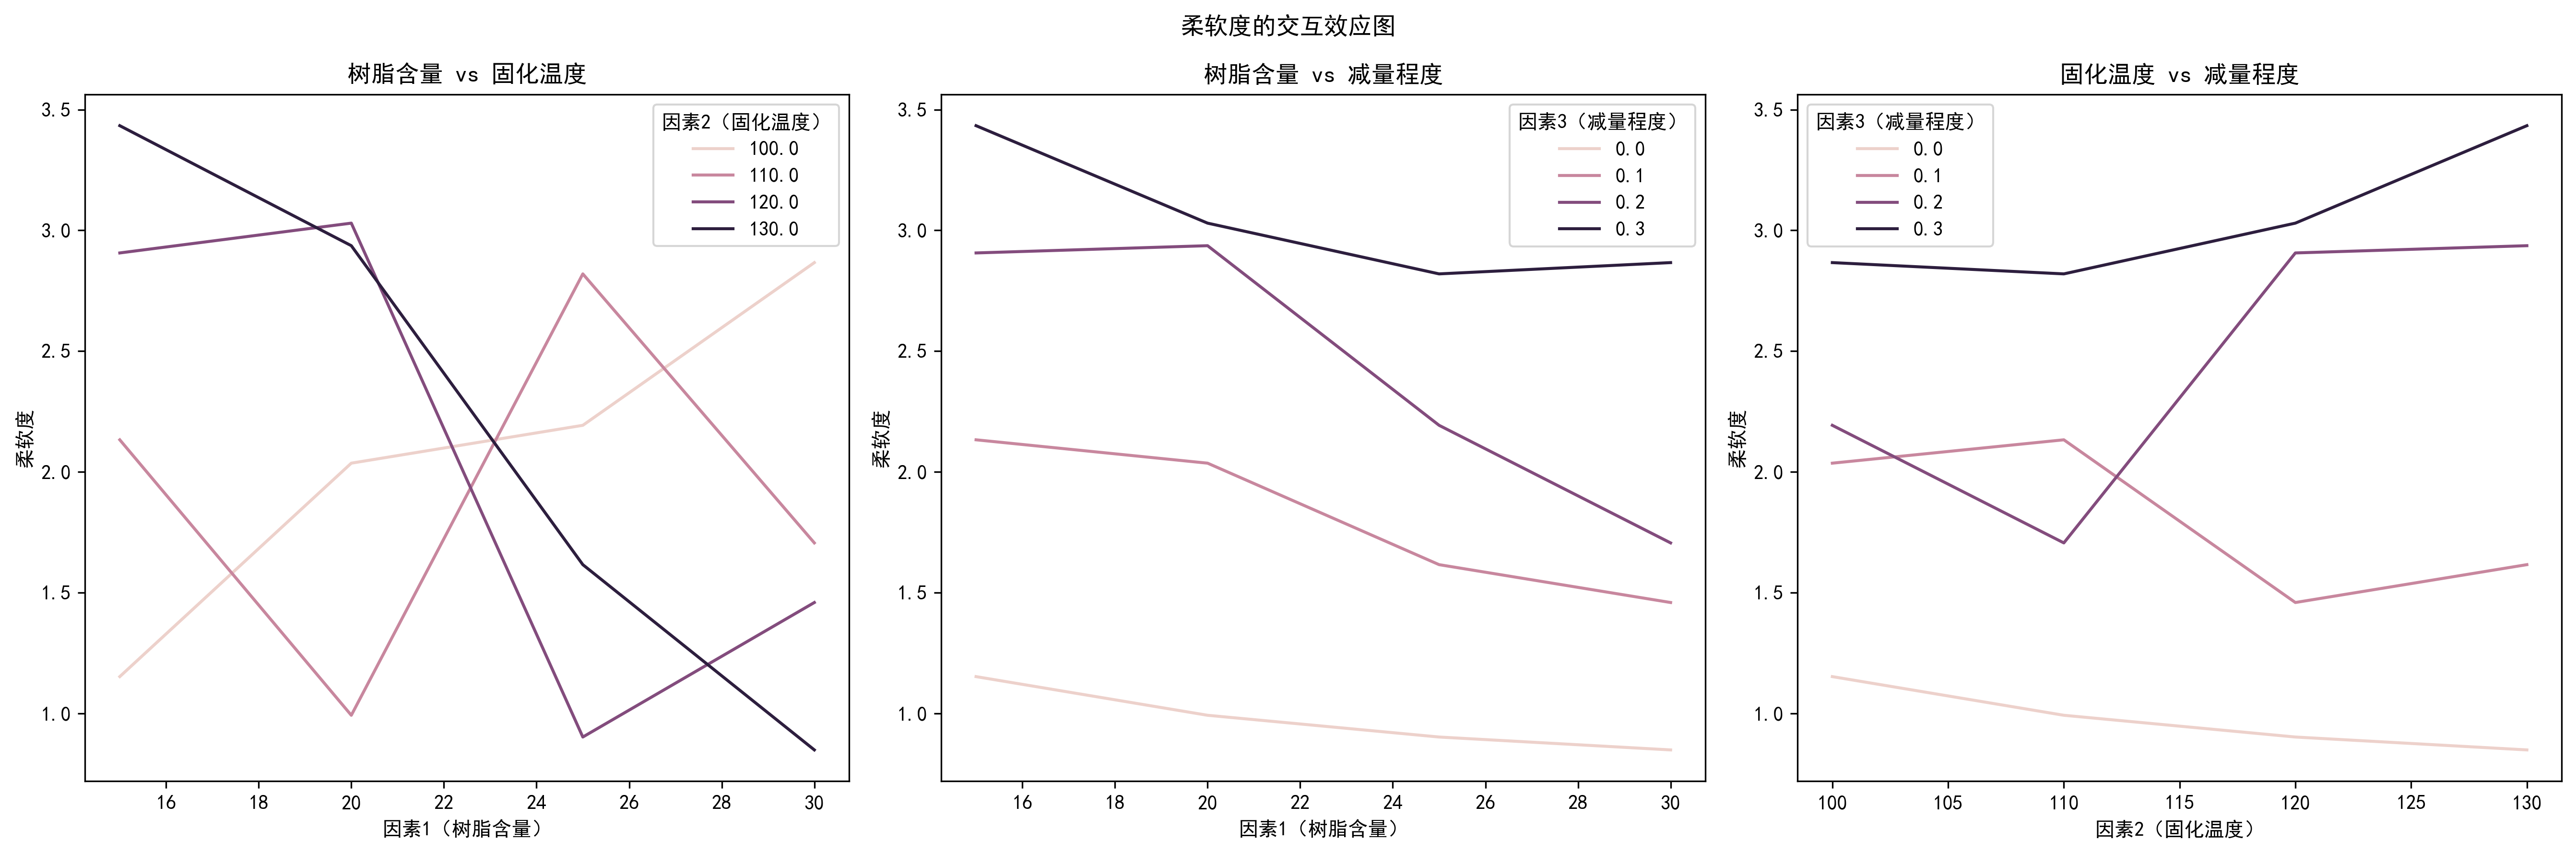

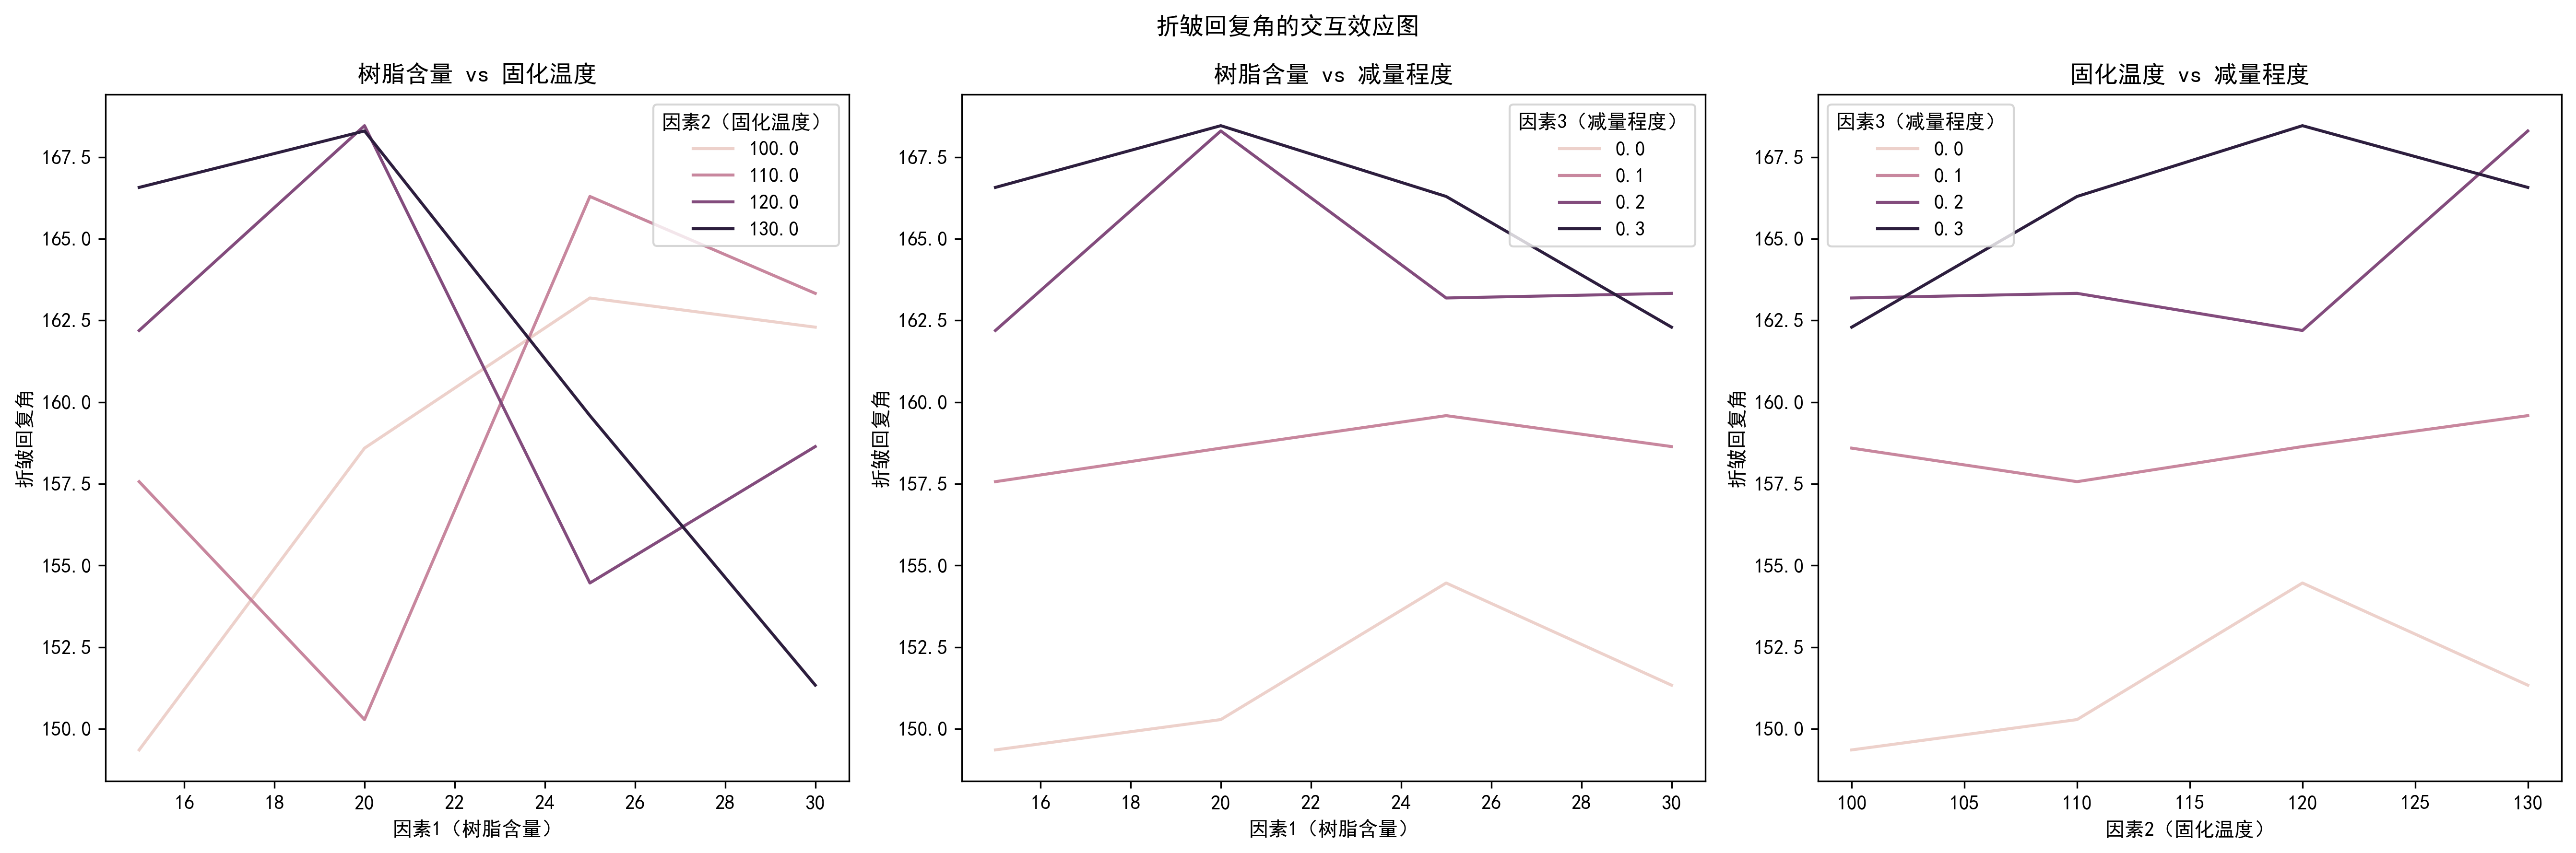

分析完成，所有图表和结果已保存。


In [64]:
# # 1. 相关性分析
# corr_pearson = scaled_data.corr(method='pearson')
# corr_spearman = scaled_data.corr(method='spearman')

# # 绘制相关性热力图
# plt.figure(figsize=(12, 10), dpi=300)
# sns.heatmap(corr_pearson, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
# plt.title('Pearson相关系数热力图')
# plt.tight_layout()
# plt.savefig('问题1_Pearson相关系数热力图.png', dpi=300)
# plt.show()

# plt.figure(figsize=(12, 10), dpi=300)
# sns.heatmap(corr_spearman, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
# plt.title('Spearman相关系数热力图')
# plt.tight_layout()
# plt.savefig('问题1_Spearman相关系数热力图.png', dpi=300)
# plt.show()

# # 2. 方差分析
# # anova_results = {}
# # for performance_metric in performance:
# #     formula = f"{performance_metric} ~ C(因素1（树脂含量）) + C(因素2（固化温度）) + C(因素3（减量程度）) + C(因素1（树脂含量）):C(因素2（固化温度）) + C(因素1（树脂含量）):C(因素3（减量程度）) + C(因素2（固化温度）):C(因素3（减量程度）)"
# #     model = ols(formula, data=merged_data).fit()
# #     anova_table = sm.stats.anova_lm(model, typ=2)
# #     anova_results[performance_metric] = anova_table

# # # 保存ANOVA结果
# # with pd.ExcelWriter('问题1_方差分析结果.xlsx') as writer:
# #     for metric, result in anova_results.items():
# #         result.to_excel(writer, sheet_name=metric)

# # 3. 主成分分析
# pca = PCA()
# pca_result = pca.fit_transform(scaled_data[performance])

# # 绘制碎石图
# plt.figure(figsize=(10, 6), dpi=300)
# plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, 'bo-')
# plt.xlabel('主成分数')
# plt.ylabel('解释方差比')
# plt.title('PCA碎石图')
# plt.tight_layout()
# plt.savefig('问题1_PCA碎石图.png', dpi=300)
# plt.show()

# # 绘制前两个主成分的散点图
# plt.figure(figsize=(10, 8), dpi=300)
# scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1], c=merged_data['因素1（树脂含量）'], cmap='viridis')
# plt.colorbar(scatter, label='树脂含量')
# plt.xlabel('第一主成分')
# plt.ylabel('第二主成分')
# plt.title('PCA散点图')
# plt.tight_layout()
# plt.savefig('问题1_PCA散点图.png', dpi=300)
# plt.show()

# # 4. 随机森林特征重要性分析
# rf_importances = {}
# for metric in performance:
#     rf = RandomForestRegressor(n_estimators=100, random_state=42)
#     rf.fit(merged_data[features], merged_data[metric])
#     importances = pd.Series(rf.feature_importances_, index=features)
#     rf_importances[metric] = importances

# # 绘制特征重要性条形图
# plt.figure(figsize=(12, 8), dpi=300)
# for i, (metric, importances) in enumerate(rf_importances.items()):
#     plt.subplot(3, 3, i+1)
#     importances.sort_values().plot(kind='barh')
#     plt.title(f'{metric}的特征重要性')
# plt.tight_layout()
# plt.savefig('问题1_随机森林特征重要性.png', dpi=300)
# plt.show()

# # 5. 交互效应可视化
# for metric in performance:
#     fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi=300)
#     fig.suptitle(f'{metric}的交互效应图')
    
#     sns.lineplot(data=merged_data, x='因素1（树脂含量）', y=metric, hue='因素2（固化温度）', ax=axes[0])
#     axes[0].set_title('树脂含量 vs 固化温度')
    
#     sns.lineplot(data=merged_data, x='因素1（树脂含量）', y=metric, hue='因素3（减量程度）', ax=axes[1])
#     axes[1].set_title('树脂含量 vs 减量程度')
    
#     sns.lineplot(data=merged_data, x='因素2（固化温度）', y=metric, hue='因素3（减量程度）', ax=axes[2])
#     axes[2].set_title('固化温度 vs 减量程度')
    
#     plt.tight_layout()
#     plt.savefig(f'问题1_{metric}交互效应图.png', dpi=300)
#     plt.show()
print('原创作者：B站北辰single，禁止倒卖发现即起诉，原创地址https://www.yuque.com/u42168770/qv6z0d/qh4iwynq2co2gy3c')
# 定义自变量和因变量
features = ['因素1（树脂含量）', '因素2（固化温度）', '因素3（减量程度）']
X = merged_data[features]
y = merged_data[performance]

print("\n自变量X的描述性统计：")
print(X.describe())

print("\n因变量y的描述性统计：")
print(y.describe())

# 标准化数据
scaler = StandardScaler()
scaled_data = pd.DataFrame(scaler.fit_transform(merged_data[features + performance]), columns=features + performance)

print("\n标准化后的数据前5行：")
print(scaled_data.head())

# 1. 相关性分析
corr_pearson = scaled_data.corr(method='pearson')
corr_spearman = scaled_data.corr(method='spearman')

print("\nPearson相关系数：")
print(corr_pearson)

print("\nSpearman相关系数：")
print(corr_spearman)

# 绘制相关性热力图
plt.figure(figsize=(12, 10), dpi=300)
sns.heatmap(corr_pearson, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Pearson相关系数热力图')
plt.tight_layout()
plt.savefig('问题1_Pearson相关系数热力图.png', dpi=300)
plt.show()

plt.figure(figsize=(12, 10), dpi=300)
sns.heatmap(corr_spearman, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Spearman相关系数热力图')
plt.tight_layout()
plt.savefig('问题1_Spearman相关系数热力图.png', dpi=300)
plt.show()

# 3. 主成分分析
pca = PCA()
pca_result = pca.fit_transform(scaled_data[performance])

print("\n主成分分析解释方差比：")
print(pca.explained_variance_ratio_)

# 绘制碎石图
plt.figure(figsize=(10, 6), dpi=300)
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, 'bo-')
plt.xlabel('主成分数')
plt.ylabel('解释方差比')
plt.title('PCA碎石图')
plt.tight_layout()
plt.savefig('问题1_PCA碎石图.png', dpi=300)
plt.show()

# 绘制前两个主成分的散点图
plt.figure(figsize=(10, 8), dpi=300)
scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1], c=merged_data['因素1（树脂含量）'], cmap='viridis')
plt.colorbar(scatter, label='树脂含量')
plt.xlabel('第一主成分')
plt.ylabel('第二主成分')
plt.title('PCA散点图')
plt.tight_layout()
plt.savefig('问题1_PCA散点图.png', dpi=300)
plt.show()

# 4. 随机森林特征重要性分析
rf_importances = {}
for metric in performance:
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(merged_data[features], merged_data[metric])
    importances = pd.Series(rf.feature_importances_, index=features)
    rf_importances[metric] = importances
    
    print(f"\n{metric}的特征重要性：")
    print(importances)

# 绘制特征重要性条形图
plt.figure(figsize=(12, 8), dpi=300)
for i, (metric, importances) in enumerate(rf_importances.items()):
    plt.subplot(3, 3, i+1)
    importances.sort_values().plot(kind='barh')
    plt.title(f'{metric}的特征重要性')
plt.tight_layout()
plt.savefig('问题1_随机森林特征重要性.png', dpi=300)
plt.show()

# 5. 交互效应可视化
for metric in performance:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi=300)
    fig.suptitle(f'{metric}的交互效应图')
    
    sns.lineplot(data=merged_data, x='因素1（树脂含量）', y=metric, hue='因素2（固化温度）', ax=axes[0])
    axes[0].set_title('树脂含量 vs 固化温度')
    
    sns.lineplot(data=merged_data, x='因素1（树脂含量）', y=metric, hue='因素3（减量程度）', ax=axes[1])
    axes[1].set_title('树脂含量 vs 减量程度')
    
    sns.lineplot(data=merged_data, x='因素2（固化温度）', y=metric, hue='因素3（减量程度）', ax=axes[2])
    axes[2].set_title('固化温度 vs 减量程度')
    
    plt.tight_layout()
    plt.savefig(f'问题1_{metric}交互效应图.png', dpi=300)
    plt.show()
print('原创作者：B站北辰single，禁止倒卖发现即起诉，原创地址https://www.yuque.com/u42168770/qv6z0d/qh4iwynq2co2gy3c')
print("分析完成，所有图表和结果已保存。")

   序号     断裂强力   断裂伸长率       撕裂强力     透气率          透湿率   柔软度    折皱回复角
0  基布  1484.79  1.2172  180.64324  201.88  3287.632509  3.66  161.983
[[1764.9416266666667, 1146.94757, 1205.34677, 1218.92149, 1162.49738, 1655.5596066666667, 1200.63958, 1235.6637166666667, 1184.1566, 1234.0107266666666, 1746.7192866666667, 1226.8778, 1258.7156666666667, 1161.7317999999998, 1184.9818066666667, 1717.9687299999998], [[1484.79]]]
None


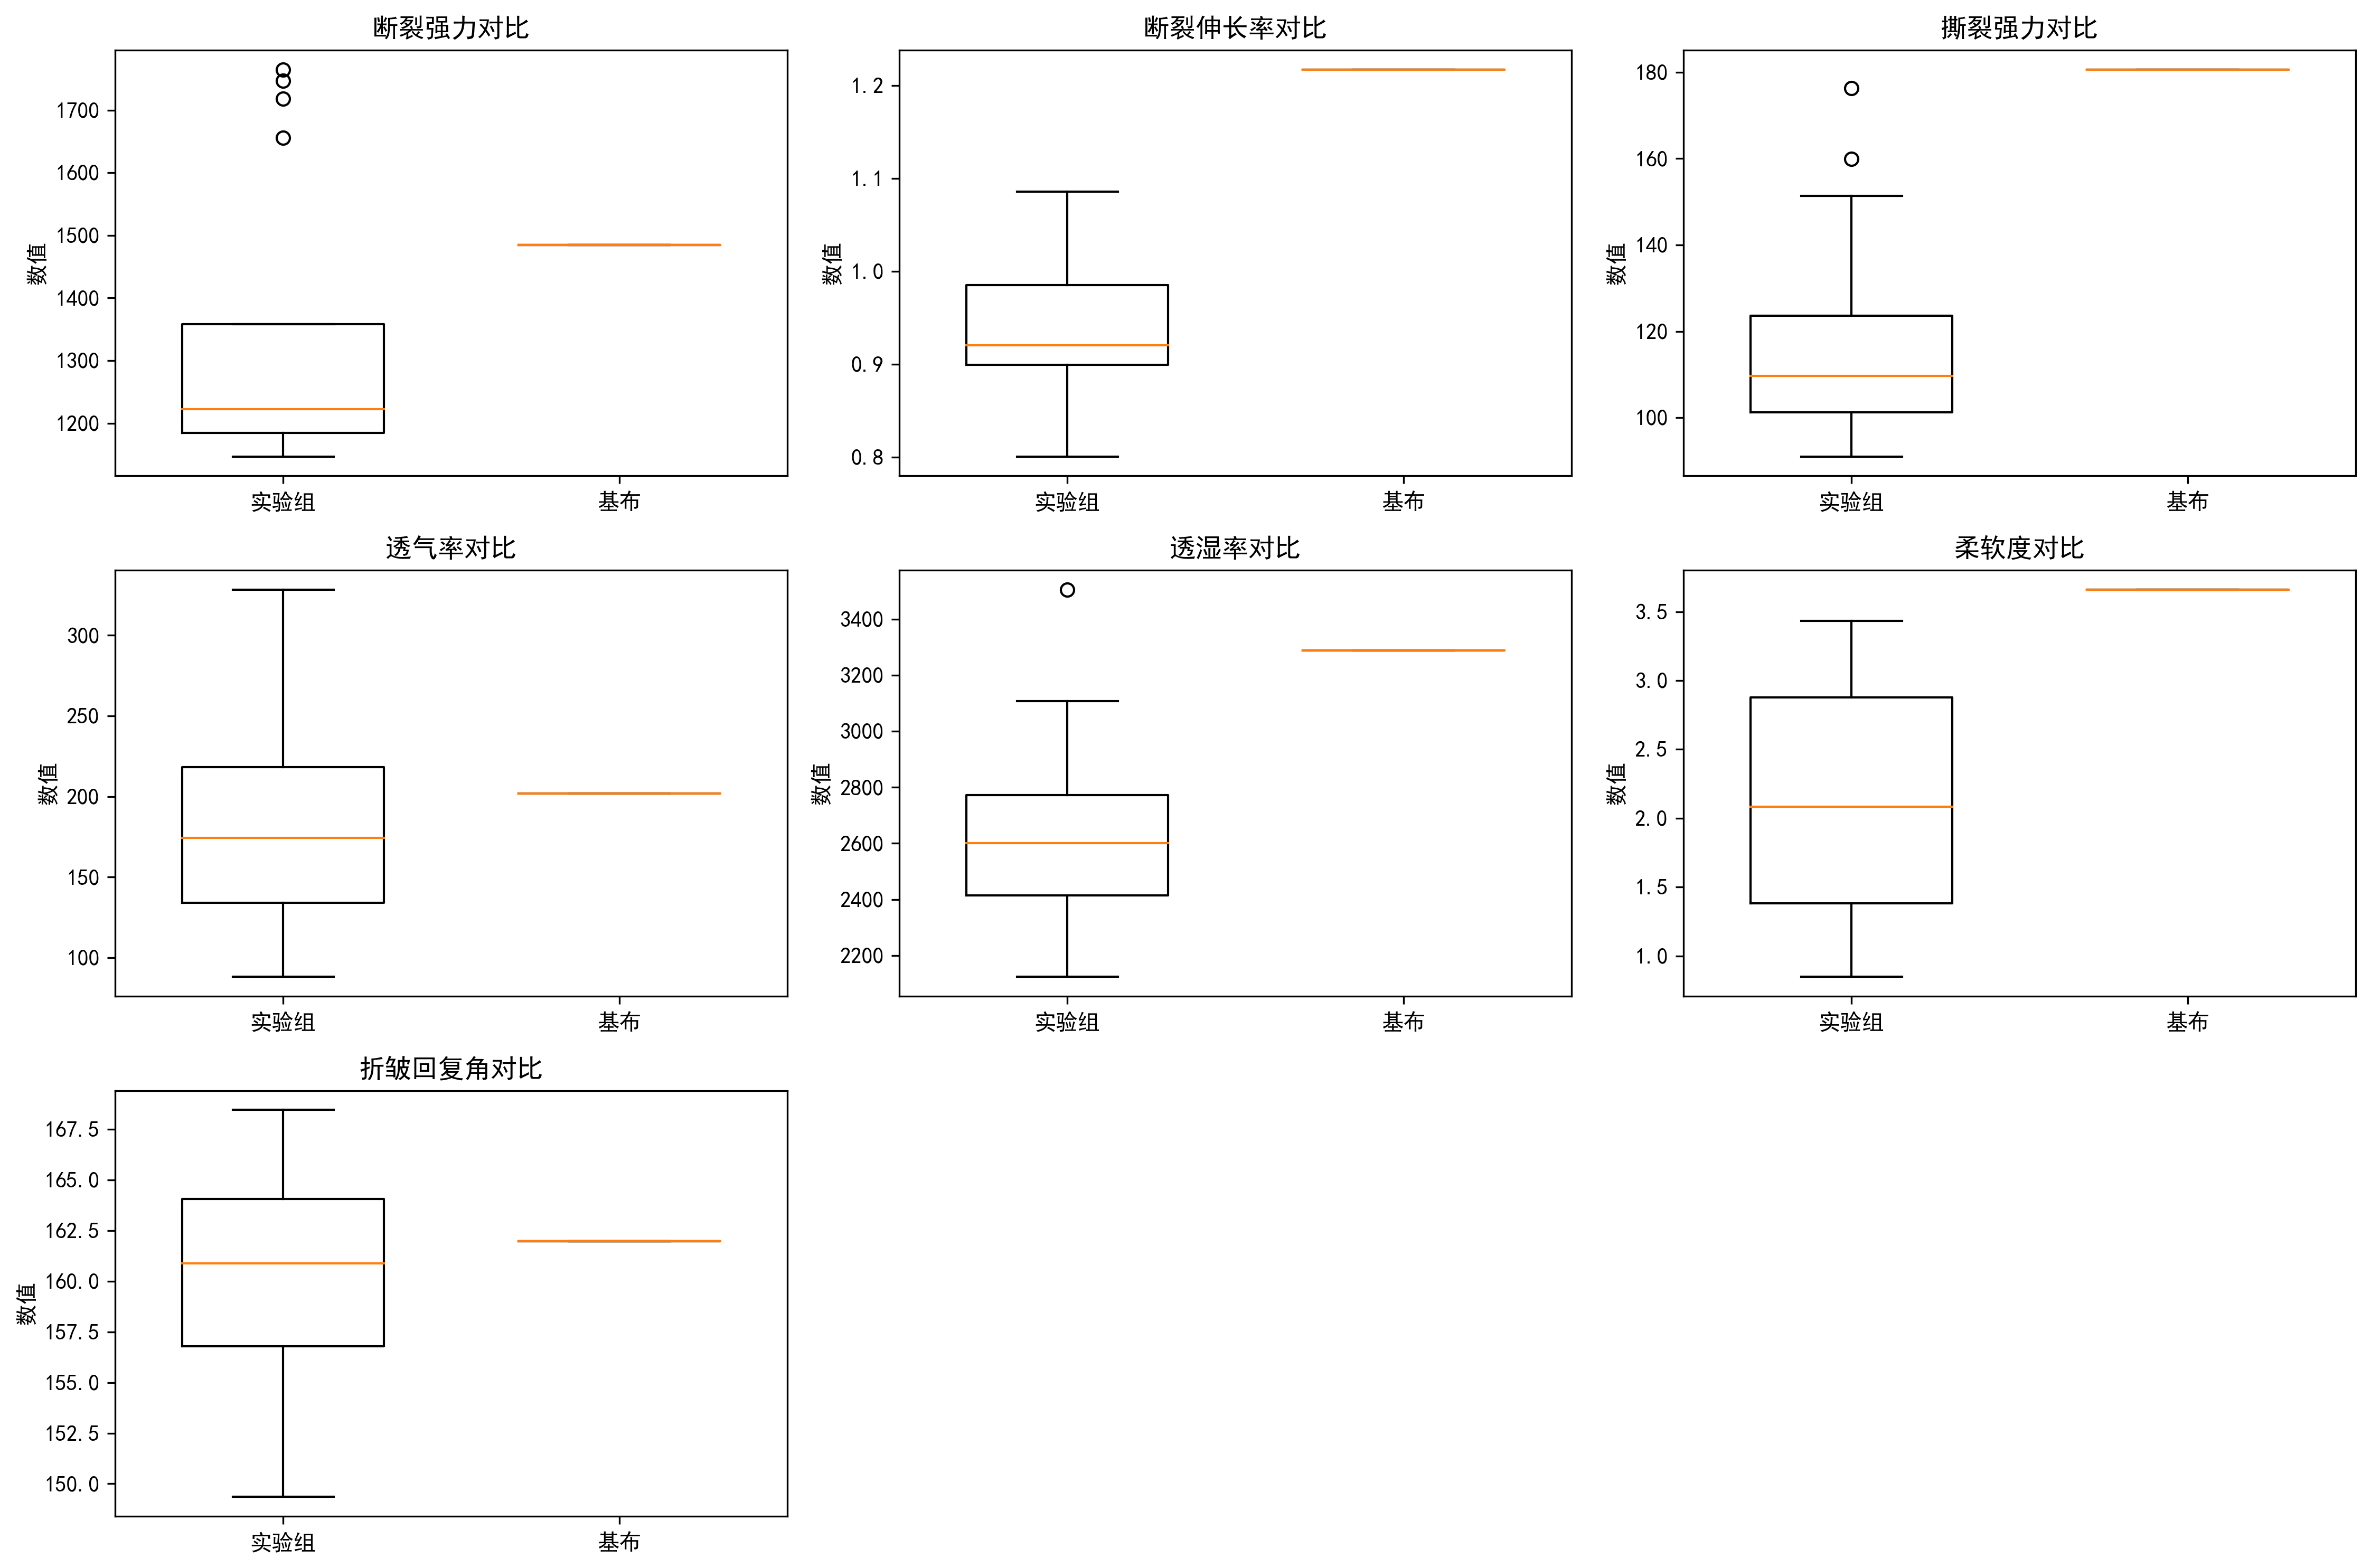

In [63]:
print(base_fabric)
print([merged_data['断裂强力'].tolist(), [base_fabric['断裂强力'].tolist()]])
print(merged_data[metric].tolist().append([base_fabric[metric].tolist()]))
# 6. 实验组数据与基布数据的可视化对比
# 6. 实验组数据与基布数据的可视化对比
plt.figure(figsize=(15, 10), dpi=300)
for i, metric in enumerate(performance):
    plt.subplot(3, 3, i+1)
    # 绘制实验组的箱线图
    bp1 = plt.boxplot(merged_data[metric].tolist(), positions=[1], widths=0.6)
    
    # 绘制基布的箱线图（实际上是一个点）
    bp2 = plt.boxplot([base_fabric[metric]], positions=[2], widths=0.6)
    
    plt.title(f'{metric}对比')
    plt.ylabel('数值')
    plt.xticks([1, 2], ['实验组', '基布'])
    
plt.tight_layout()
plt.savefig('问题1_实验组与基布对比.png', dpi=300)
plt.show()
print('原创作者：B站北辰single，禁止倒卖发现即起诉，原创地址https://www.yuque.com/u42168770/qv6z0d/qh4iwynq2co2gy3c')